In [ ]:
!wget --progress=bar:force https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_Unlabelled.h58

--2026-03-01 06:16:45--  https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_Unlabelled.h5
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.106, 128.55.206.107, 128.55.206.108, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30000002048 (28G)
Saving to: ‘Dataset_Specific_Unlabelled.h5’

Dataset_Specific_Un 100%[===================>]  27.94G  29.6MB/s    in 16m 55s 

2026-03-01 06:33:41 (28.2 MB/s) - ‘Dataset_Specific_Unlabelled.h5’ saved [30000002048/30000002048]



In [ ]:
import h5py

file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")

key = list(file.keys())[0]

full_data = file[key]

print("Total samples:", len(full_data))

file.close()

Total samples: 60000


In [ ]:
file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")

def print_structure(name, obj):
    print(f"{name} -> {type(obj)}")

file.visititems(print_structure)

jet -> <class 'h5py._hl.dataset.Dataset'>


In [ ]:
file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")

data = file["jet"]

print("Shape:", data.shape)
print("Datatype:", data.dtype)

# calculate size in GB
size_gb = data.size * data.dtype.itemsize / (1024**3)
print("Dataset size (GB):", size_gb)

file.close()

Shape: (60000, 125, 125, 8)
Datatype: float32
Dataset size (GB): 27.939677238464355


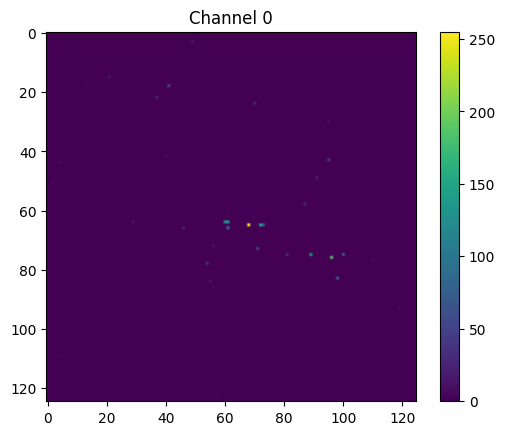

In [ ]:
import matplotlib.pyplot as plt

file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")

jet = file["jet"]

sample = jet[0]

plt.imshow(sample[:,:,0])
plt.colorbar()
plt.title("Channel 0")
plt.show()

file.close()

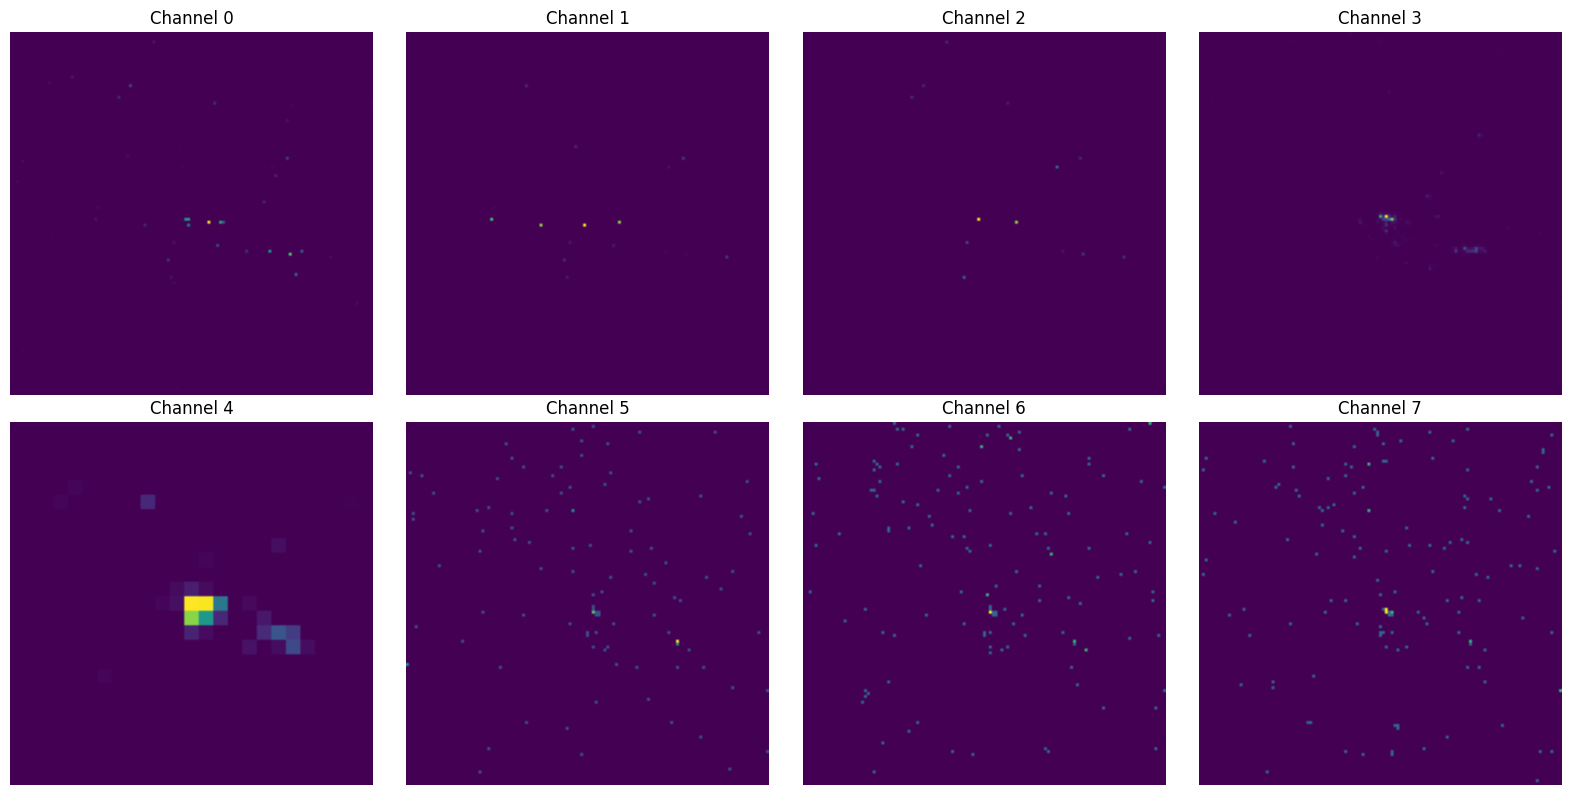

In [ ]:
file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")

jet = file["jet"]

sample = jet[0]

plt.figure(figsize=(16,8))

for i in range(8):

    plt.subplot(2,4,i+1)
    plt.imshow(sample[:,:,i])
    plt.title(f"Channel {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

file.close()

# **Resize dataset to 32×32**

In [ ]:
import numpy as np
import cv2

# open original file
file = h5py.File("Dataset_Specific_Unlabelled.h5", "r")
jet = file["jet"]

N = len(jet)

# create new file
new_file = h5py.File("cms_jet_32x32.h5", "w")

# create empty dataset
resized_dataset = new_file.create_dataset(
    "jet",
    shape=(N, 32, 32, 8),
    dtype="float32"
)

batch_size = 500

for i in range(0, N, batch_size):

    batch = jet[i:i+batch_size]

    resized_batch = np.zeros((len(batch), 32, 32, 8), dtype=np.float32)

    for j in range(len(batch)):
        for ch in range(8):
            resized_batch[j,:,:,ch] = cv2.resize(
                batch[j,:,:,ch],
                (32,32),
                interpolation=cv2.INTER_AREA
            )

    resized_dataset[i:i+batch_size] = resized_batch

    print(f"Processed {i}/{N}")

file.close()
new_file.close()

print("Done. Saved as cms_jet_32x32.h5")


Processed 0/60000
Processed 500/60000
Processed 1000/60000
Processed 1500/60000
Processed 2000/60000
Processed 2500/60000
Processed 3000/60000
Processed 3500/60000
Processed 4000/60000
Processed 4500/60000
Processed 5000/60000
Processed 5500/60000
Processed 6000/60000
Processed 6500/60000
Processed 7000/60000
Processed 7500/60000
Processed 8000/60000
Processed 8500/60000
Processed 9000/60000
Processed 9500/60000
Processed 10000/60000
Processed 10500/60000
Processed 11000/60000
Processed 11500/60000
Processed 12000/60000
Processed 12500/60000
Processed 13000/60000
Processed 13500/60000
Processed 14000/60000
Processed 14500/60000
Processed 15000/60000
Processed 15500/60000
Processed 16000/60000
Processed 16500/60000
Processed 17000/60000
Processed 17500/60000
Processed 18000/60000
Processed 18500/60000
Processed 19000/60000
Processed 19500/60000
Processed 20000/60000
Processed 20500/60000
Processed 21000/60000
Processed 21500/60000
Processed 22000/60000
Processed 22500/60000
Processed 23

In [ ]:
import h5py

f = h5py.File("cms_jet_32x32.h5", "r")
print("Shape:", f["jet"].shape)
print("Dtype:", f["jet"].dtype)
print("Min:", f["jet"][0].min())
print("Max:", f["jet"][0].max())
f.close()

Shape: (60000, 32, 32, 8)
Dtype: float32
Min: 0.0
Max: 228.74883


# **Inspect each channel**

Ch0: sparsity=92.6%  max=68.551  mean_hits=76.3  median_hits=75.0
Ch1: sparsity=96.3%  max=42.009  mean_hits=38.0  median_hits=37.0
Ch2: sparsity=97.8%  max=42.074  mean_hits=23.0  median_hits=22.0
Ch3: sparsity=89.7%  max=143.205  mean_hits=105.6  median_hits=96.0
Ch4: sparsity=90.3%  max=255.000  mean_hits=99.5  median_hits=101.0
Ch5: sparsity=83.0%  max=141.527  mean_hits=173.9  median_hits=166.0
Ch6: sparsity=80.6%  max=117.371  mean_hits=198.8  median_hits=192.0
Ch7: sparsity=80.6%  max=134.738  mean_hits=198.4  median_hits=192.0


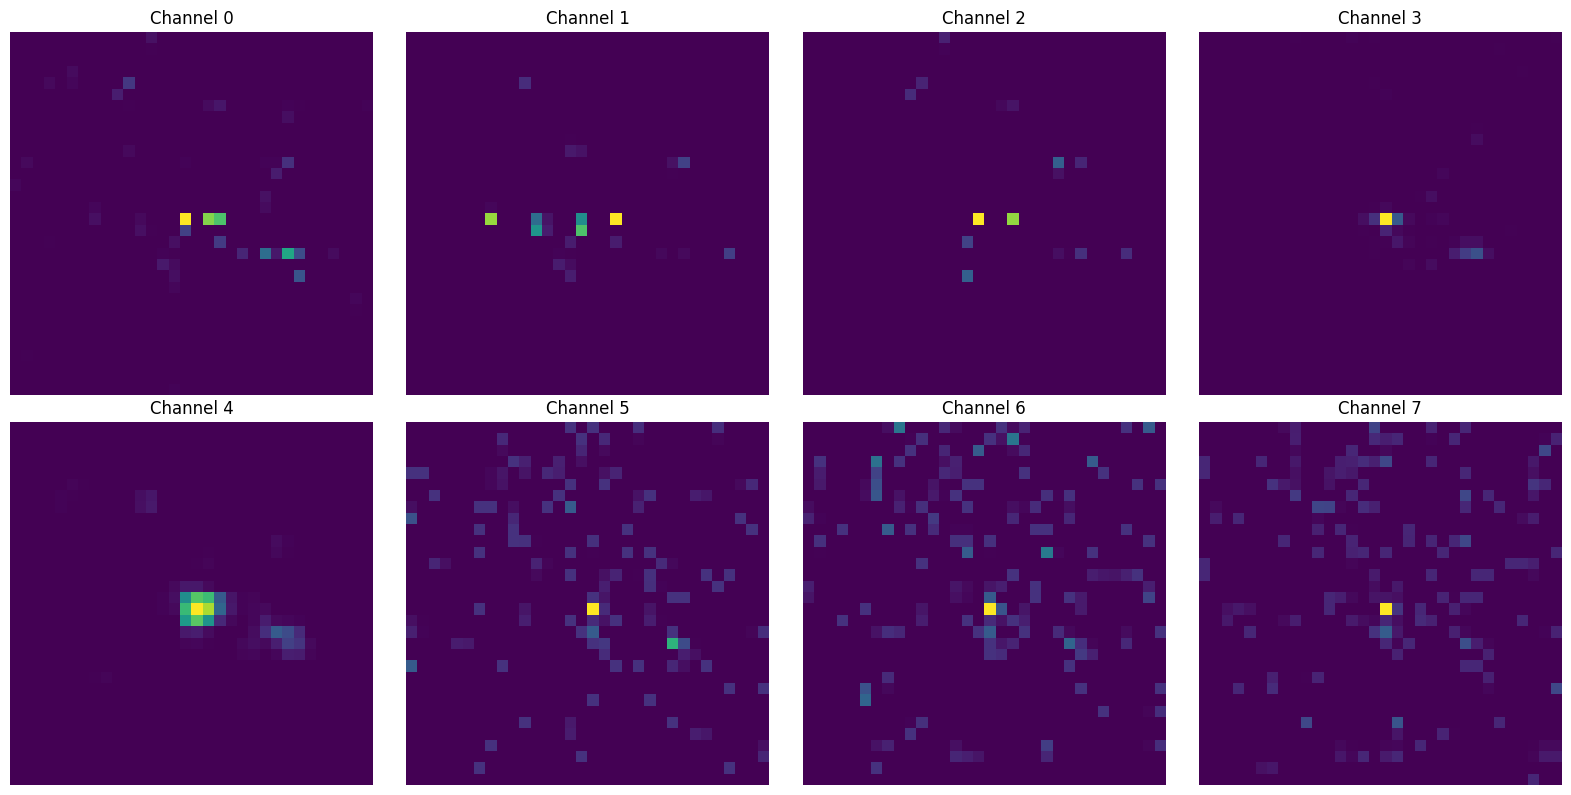

Done


In [ ]:
import numpy as np
from matplotlib import pyplot as plt

f = h5py.File("cms_jet_32x32.h5", "r")
X = f["jet"][:]
f.close()

# Channel statistics
for ch in range(8):
    data = X[:,:,:,ch]
    nonzero = (data > 0).sum(axis=(1,2))
    print(f"Ch{ch}: sparsity={( data==0).mean()*100:.1f}%  "
          f"max={data.max():.3f}  "
          f"mean_hits={nonzero.mean():.1f}  "
          f"median_hits={np.median(nonzero):.1f}")

# Visualize one sample
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample = X[0]
for ch in range(8):
    ax = axes[ch//4, ch%4]
    ax.imshow(sample[:,:,ch], cmap='viridis')
    ax.set_title(f"Channel {ch}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("channel_inspection.png", dpi=150)
plt.show()
print("Done")

# **Normalize the data**

In [ ]:
f = h5py.File("cms_jet_32x32.h5", "r")
X = f["jet"][:]  # (60000, 32, 32, 8)
f.close()

# Step 1: log1p to compress dynamic range (handles sparsity well)
X = np.log1p(X)

# Step 2: per-channel normalization to [-1, 1]
channel_stats = {}
for ch in range(8):
    ch_min = X[:,:,:,ch].min()
    ch_max = X[:,:,:,ch].max()
    channel_stats[ch] = (ch_min, ch_max)
    if ch_max - ch_min > 1e-8:
        X[:,:,:,ch] = 2 * (X[:,:,:,ch] - ch_min) / (ch_max - ch_min) - 1

print("After normalization:")
for ch in range(8):
    print(f"Ch{ch}: min={X[:,:,:,ch].min():.3f}  max={X[:,:,:,ch].max():.3f}  mean={X[:,:,:,ch].mean():.4f}")

# Save stats for later (needed to unnormalize generated samples)
np.save("channel_stats.npy", channel_stats)
print("\nChannel stats saved.")

After normalization:
Ch0: min=-1.000  max=1.000  mean=-0.9853
Ch1: min=-1.000  max=1.000  mean=-0.9828
Ch2: min=-1.000  max=1.000  mean=-0.9895
Ch3: min=-1.000  max=1.000  mean=-0.9842
Ch4: min=-1.000  max=1.000  mean=-0.9400
Ch5: min=-1.000  max=1.000  mean=-0.8770
Ch6: min=-1.000  max=1.000  mean=-0.8599
Ch7: min=-1.000  max=1.000  mean=-0.8666

Channel stats saved.


# **Convert to PyTorch and create dataloaders**

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# Convert to PyTorch — change from (N, H, W, C) to (N, C, H, W)
X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
print("Tensor shape:", X_tensor.shape)  # should be (60000, 8, 32, 32)

# Train/test split — 50k train, 10k test
dataset = TensorDataset(X_tensor)
train_ds, test_ds = random_split(dataset, [50000, 10000],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Tensor shape: torch.Size([60000, 8, 32, 32])
Train batches: 782
Test batches:  157


# **Build the DDPM components**

 Sinusoidal Embedding

In [ ]:
import torch
import torch.nn as nn
import math

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

print("SinusoidalPosEmb defined")

SinusoidalPosEmb defined


 ResBlock

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.res_conv(x)

print("ResBlock defined")

ResBlock defined


U-Net

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, time_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )

        # Encoder
        self.enc1 = ResBlock(in_ch,      base_ch,   time_dim)
        self.enc2 = ResBlock(base_ch,    base_ch*2, time_dim)
        self.enc3 = ResBlock(base_ch*2,  base_ch*4, time_dim)

        self.down1 = nn.MaxPool2d(2)
        self.down2 = nn.MaxPool2d(2)
        self.down3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bot = ResBlock(base_ch*4, base_ch*4, time_dim)

        # Decoder
        self.up3  = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, stride=2)
        self.dec3 = ResBlock(base_ch*8, base_ch*2, time_dim)

        self.up2  = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, stride=2)
        self.dec2 = ResBlock(base_ch*4, base_ch,   time_dim)

        self.up1  = nn.ConvTranspose2d(base_ch, base_ch, 2, stride=2)
        self.dec1 = ResBlock(base_ch*2, base_ch,   time_dim)

        self.out  = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_emb(t)

        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.down1(e1), t_emb)
        e3 = self.enc3(self.down2(e2), t_emb)

        b  = self.bot(self.down3(e3), t_emb)

        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1), t_emb)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)

        return self.out(d1)

print("UNet defined")

UNet defined


# **Test the U-Net with a dummy forward pass**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_ch=8, base_ch=64, time_dim=128).to(device)

x_dummy = torch.randn(4, 8, 32, 32).to(device)
t_dummy = torch.randint(0, 1000, (4,)).to(device)
out = model(x_dummy, t_dummy)

print("Input shape: ", x_dummy.shape)
print("Output shape:", out.shape)
print("Params:", sum(p.numel() for p in model.parameters()) / 1e6, "M")
print("Device:", device)

Input shape:  torch.Size([4, 8, 32, 32])
Output shape: torch.Size([4, 8, 32, 32])
Params: 4.032072 M
Device: cpu


 DDPM Noise Schedule

In [ ]:
class DDPM:
    def __init__(self, T=500, device='cuda'):
        self.T = T
        self.device = device

        # Cosine noise schedule
        steps = torch.arange(T + 1, dtype=torch.float32) / T
        alphas_cumprod = torch.cos((steps + 0.008) / 1.008 * math.pi / 2) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]

        self.betas = torch.clamp(1 - alphas_cumprod[1:] / alphas_cumprod[:-1], 0.0001, 0.9999).to(device)
        self.alphas = (1 - self.betas).to(device)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)

    def add_noise(self, x0, t):
        """Forward process: add noise to x0 at timestep t"""
        eps = torch.randn_like(x0)
        ab = self.alpha_bars[t][:, None, None, None]
        xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * eps
        return xt, eps

    def denoise_step(self, model, xt, t_val):
        """One reverse step"""
        t_tensor = torch.full((xt.shape[0],), t_val, device=self.device, dtype=torch.long)
        with torch.no_grad():
            eps_pred = model(xt, t_tensor)

        beta = self.betas[t_val]
        alpha = self.alphas[t_val]
        alpha_bar = self.alpha_bars[t_val]

        mean = (1 / torch.sqrt(alpha)) * (xt - (beta / torch.sqrt(1 - alpha_bar)) * eps_pred)

        if t_val > 0:
            noise = torch.randn_like(xt)
            return mean + torch.sqrt(beta) * noise
        return mean

ddpm = DDPM(T=500, device=device)
print("Alpha bar at t=0:  ", ddpm.alpha_bars[0].item())
print("Alpha bar at t=250:", ddpm.alpha_bars[249].item())
print("Alpha bar at t=499:", ddpm.alpha_bars[499].item())
print("DDPM ready")

Alpha bar at t=0:   0.9998999834060669
Alpha bar at t=250: 0.4938374161720276
Alpha bar at t=499: 9.715935833654044e-10
DDPM ready


Test add_noise first

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


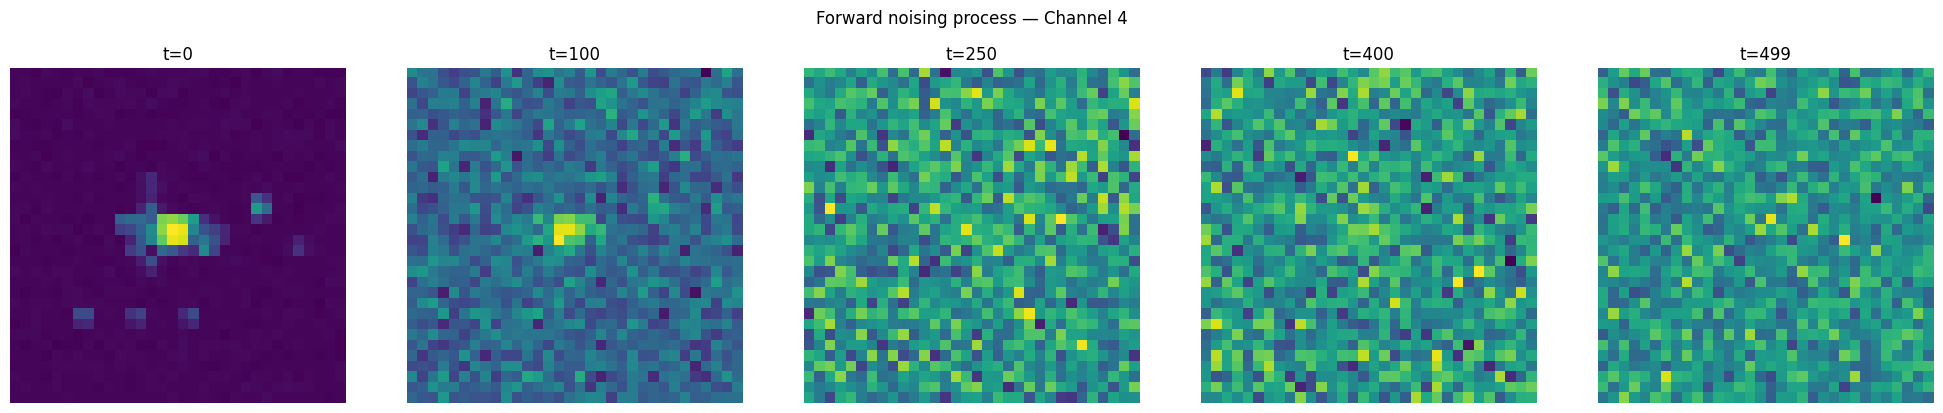

Done


In [ ]:
# grab one real batch
sample_batch = next(iter(train_loader))[0].to(device)
x0 = sample_batch[:1]  # just one image

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
timesteps_to_show = [0, 100, 250, 400, 499]

for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val], device=device)
    xt, _ = ddpm.add_noise(x0, t_tensor)
    # show channel 4 (most informative)
    img = xt[0, 4].cpu().numpy()
    ax.imshow(img, cmap='viridis')
    ax.set_title(f"t={t_val}")
    ax.axis('off')

plt.suptitle("Forward noising process — Channel 4", y=1.02)
plt.tight_layout()
plt.savefig("noise_test.png", dpi=150)
plt.show()
print("Done")

# **Training Loop**

In [ ]:
from tqdm.auto import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

EPOCHS = 50
losses = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch in pbar:
        x0 = batch[0].to(device)
        t  = torch.randint(0, ddpm.T, (x0.shape[0],), device=device)

        xt, eps  = ddpm.add_noise(x0, t)
        eps_pred = model(xt, t)
        loss     = nn.functional.mse_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.6f}")

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Avg Loss: {avg_loss:.6f}")

print("\nTraining complete")

# **Plot the loss curve**

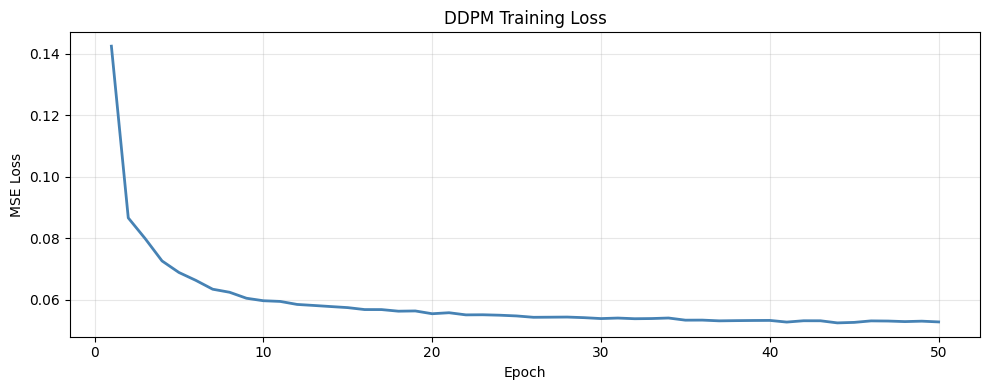

Done


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(losses)+1), losses, color='steelblue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Done")

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'losses': losses,
    'epoch': 50,
}, 'ddpm_cms_jet.pt')

print("Model saved as ddpm_cms_jet.pt")

Model saved as ddpm_cms_jet.pt


# **Generate samples using DDIM (fast sampling)**

In [ ]:
@torch.no_grad()
def ddim_sample(model, ddpm, n_samples=16, steps=50, device='cuda'):
    model.eval()

    # start from pure noise
    x = torch.randn(n_samples, 8, 32, 32, device=device)

    # select subset of timesteps
    timesteps = torch.linspace(ddpm.T - 1, 0, steps).long()

    for i, t_val in enumerate(tqdm(timesteps, desc="Sampling")):
        t_tensor = torch.full((n_samples,), t_val, device=device, dtype=torch.long)

        ab      = ddpm.alpha_bars[t_val]
        ab_prev = ddpm.alpha_bars[timesteps[i+1]] if i < len(timesteps)-1 else torch.tensor(1.0)

        eps_pred = model(x, t_tensor)

        # predicted x0
        x0_pred = (x - torch.sqrt(1 - ab) * eps_pred) / torch.sqrt(ab)
        x0_pred = torch.clamp(x0_pred, -1, 1)

        # DDIM update
        x = torch.sqrt(ab_prev) * x0_pred + torch.sqrt(1 - ab_prev) * eps_pred

    return x

# Generate 1000 samples for statistical tests
print("Generating 1000 samples...")
all_generated = []
for i in range(0, 1000, 64):
    n = min(64, 1000 - i)
    samples = ddim_sample(model, ddpm, n_samples=n, steps=50, device=device)
    all_generated.append(samples.cpu())
    print(f"Generated {i+n}/1000")

generated = torch.cat(all_generated, dim=0)
print("Generated shape:", generated.shape)

Generating 1000 samples...


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 64/1000


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 128/1000


...

Generated 896/1000


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 960/1000


Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 1000/1000
Generated shape: torch.Size([1000, 8, 32, 32])


 Get real test samples for comparison

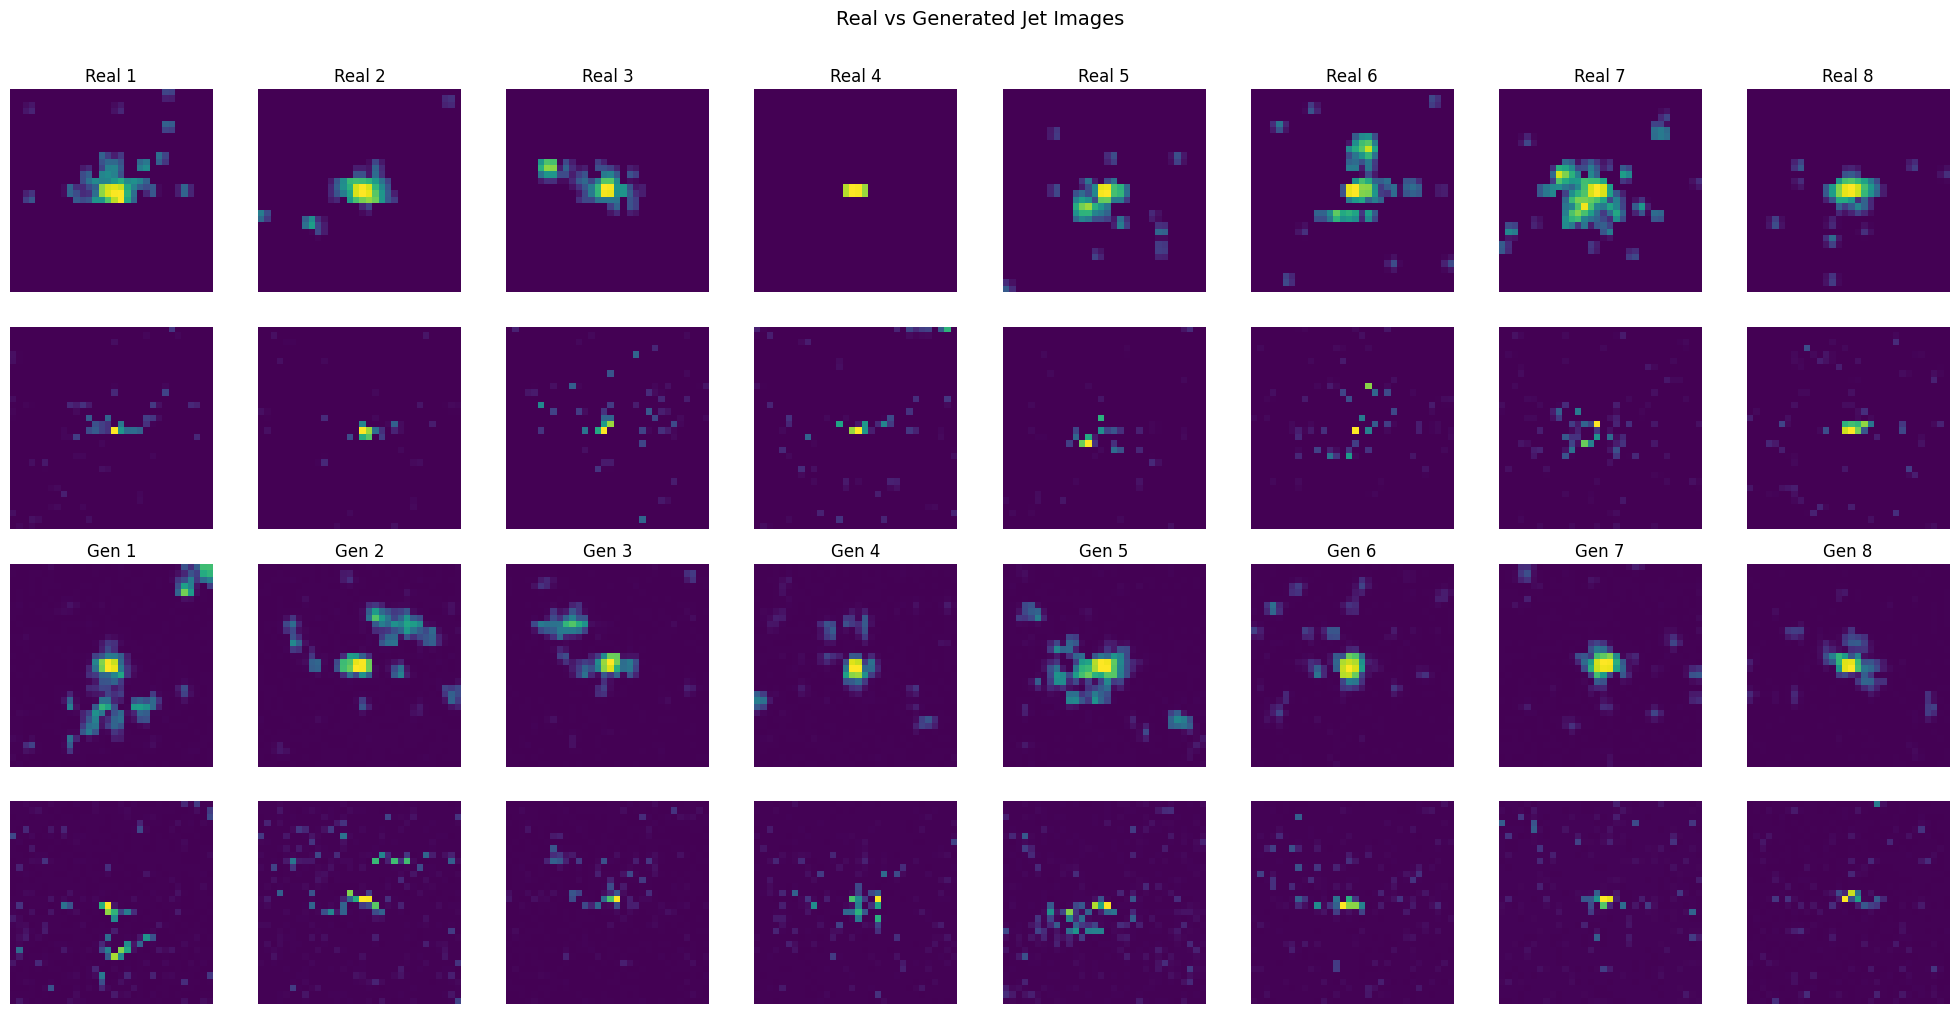

Done


In [ ]:
# get 8 real samples from test set for comparison
real_samples = next(iter(test_loader))[0][:8]

fig, axes = plt.subplots(4, 8, figsize=(20, 10))

for i in range(8):
    # Row 0-1: Real samples — ch4 and ch0
    axes[0, i].imshow(real_samples[i, 4].cpu().numpy(), cmap='viridis')
    axes[0, i].set_title(f"Real {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(real_samples[i, 0].cpu().numpy(), cmap='viridis')
    axes[1, i].axis('off')

    # Row 2-3: Generated samples — ch4 and ch0
    axes[2, i].imshow(generated[i, 4].cpu().numpy(), cmap='viridis')
    axes[2, i].set_title(f"Gen {i+1}")
    axes[2, i].axis('off')

    axes[3, i].imshow(generated[i, 0].cpu().numpy(), cmap='viridis')
    axes[3, i].axis('off')

# row labels
for row, label in zip([0,1,2,3], ["Real Ch4","Real Ch0","Gen Ch4","Gen Ch0"]):
    axes[row, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=40)

plt.suptitle("Real vs Generated Jet Images", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("real_vs_generated.png", dpi=150)
plt.show()
print("Done")

Collect real test samples

In [ ]:
real_list = []
for batch in test_loader:
    real_list.append(batch[0])
    if torch.cat(real_list).shape[0] >= 1000:
        break

real = torch.cat(real_list)[:1000]  # (1000, 8, 32, 32)

print("Real samples shape:     ", real.shape)
print("Generated samples shape:", generated.shape)

Real samples shape:      torch.Size([1000, 8, 32, 32])
Generated samples shape: torch.Size([1000, 8, 32, 32])


# **Statistical Test 1 — Pixel Intensity Distribution (Wasserstein Distance)**

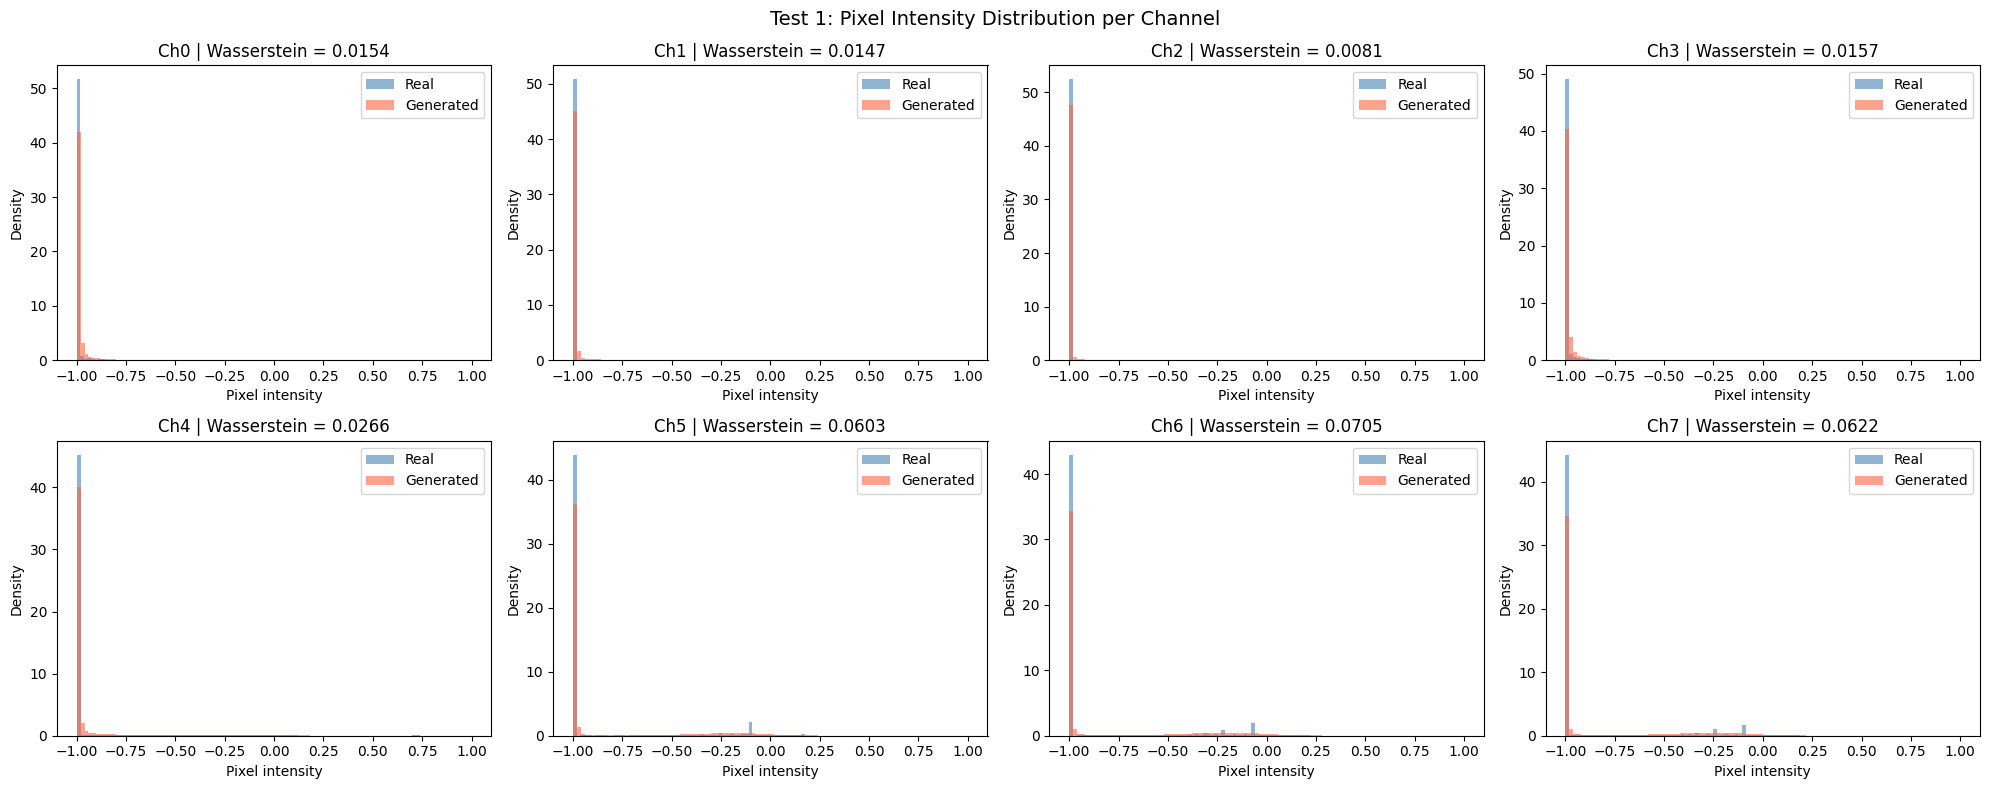


Wasserstein distances per channel:
  Ch0: 0.0154
  Ch1: 0.0147
  Ch2: 0.0081
  Ch3: 0.0157
  Ch4: 0.0266
  Ch5: 0.0603
  Ch6: 0.0705
  Ch7: 0.0622

Mean Wasserstein: 0.0342


In [ ]:
from scipy.stats import wasserstein_distance
import matplotlib.

real_np = real.numpy()
gen_np  = generated.numpy()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
w_distances = []

for ch in range(8):
    ax = axes[ch//4, ch%4]

    r = real_np[:, ch, :, :].flatten()
    g = gen_np[:,  ch, :, :].flatten()

    wd = wasserstein_distance(r, g)
    w_distances.append(wd)

    ax.hist(r, bins=100, alpha=0.6, color='steelblue', label='Real',      density=True)
    ax.hist(g, bins=100, alpha=0.6, color='tomato',    label='Generated', density=True)
    ax.set_title(f"Ch{ch} | Wasserstein = {wd:.4f}")
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Test 1: Pixel Intensity Distribution per Channel", fontsize=14)
plt.tight_layout()
plt.savefig("test1_pixel_intensity.png", dpi=150)
plt.show()

print("\nWasserstein distances per channel:")
for ch, wd in enumerate(w_distances):
    print(f"  Ch{ch}: {wd:.4f}")
print(f"\nMean Wasserstein: {np.mean(w_distances):.4f}")

# **Statistical Test 2 — Hit Multiplicity (Sparsity Test)**

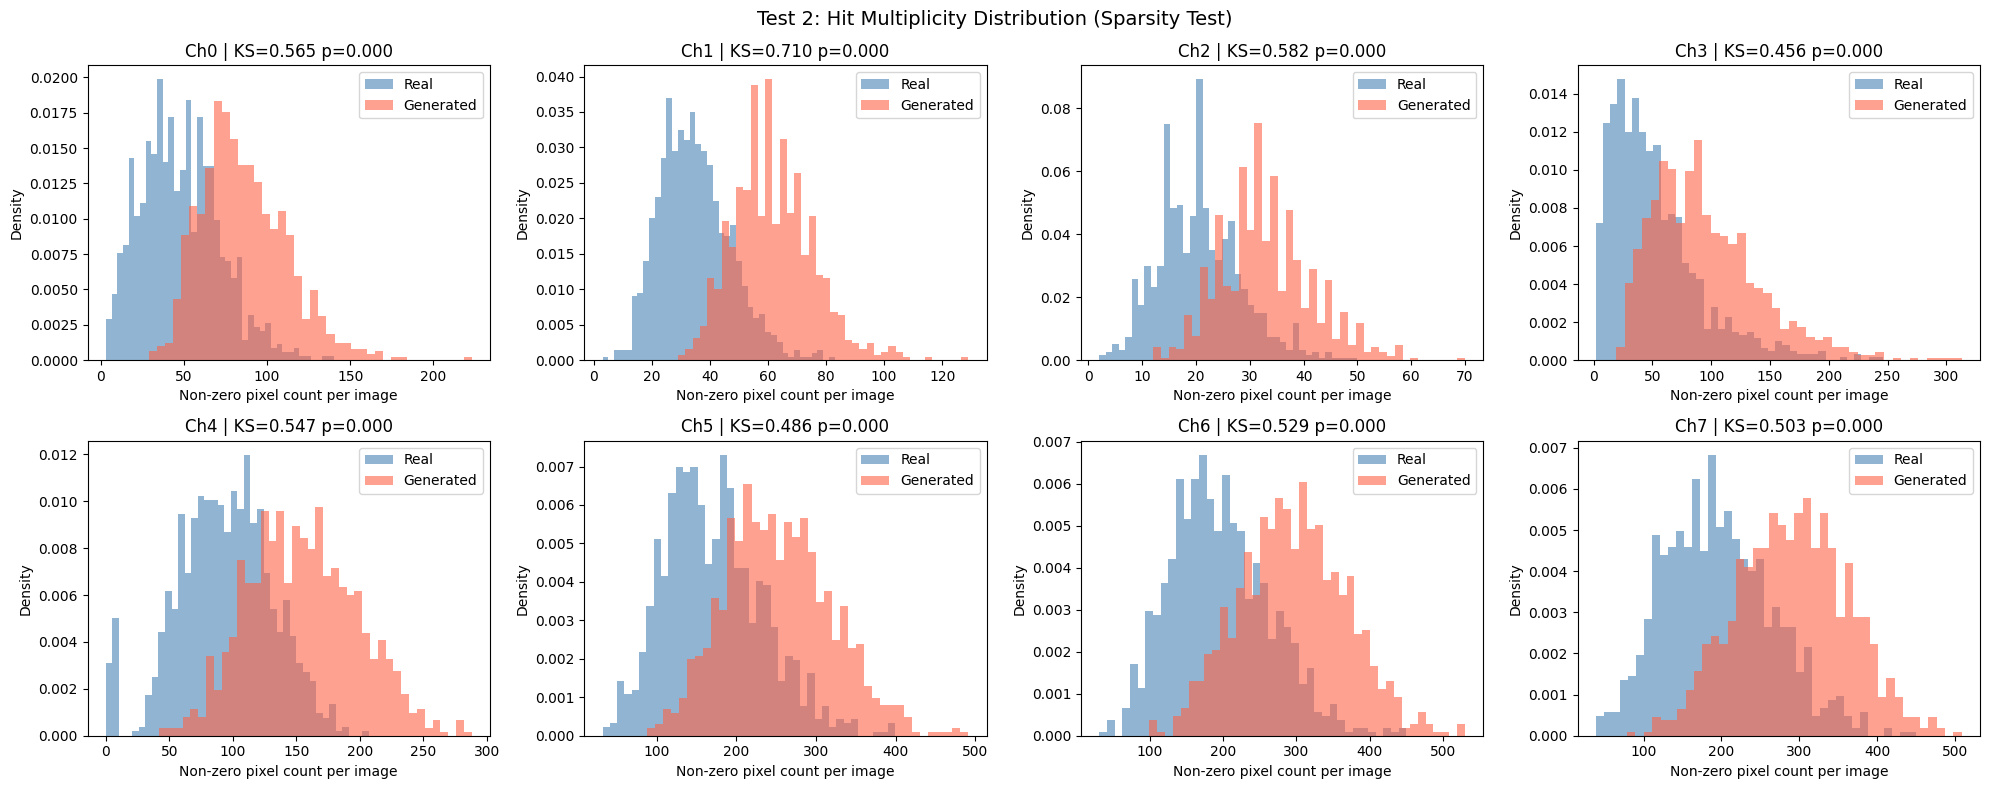


KS Test results per channel:
  Ch0: KS=0.5650  p=0.0000  [FAIL]
  Ch1: KS=0.7100  p=0.0000  [FAIL]
  Ch2: KS=0.5820  p=0.0000  [FAIL]
  Ch3: KS=0.4560  p=0.0000  [FAIL]
  Ch4: KS=0.5470  p=0.0000  [FAIL]
  Ch5: KS=0.4860  p=0.0000  [FAIL]
  Ch6: KS=0.5290  p=0.0000  [FAIL]
  Ch7: KS=0.5030  p=0.0000  [FAIL]


In [ ]:
from scipy.stats import ks_2samp

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
ks_stats = []

for ch in range(8):
    ax = axes[ch//4, ch%4]

    # count non-zero pixels per image per channel
    threshold = -0.95  # slightly above -1 to catch non-zero pixels
    real_hits = (real_np[:, ch, :, :] > threshold).sum(axis=(1,2))
    gen_hits  = (gen_np[:,  ch, :, :] > threshold).sum(axis=(1,2))

    ks_stat, p_val = ks_2samp(real_hits, gen_hits)
    ks_stats.append((ks_stat, p_val))

    ax.hist(real_hits, bins=40, alpha=0.6, color='steelblue', label='Real',      density=True)
    ax.hist(gen_hits,  bins=40, alpha=0.6, color='tomato',    label='Generated', density=True)
    ax.set_title(f"Ch{ch} | KS={ks_stat:.3f} p={p_val:.3f}")
    ax.set_xlabel("Non-zero pixel count per image")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Test 2: Hit Multiplicity Distribution (Sparsity Test)", fontsize=14)
plt.tight_layout()
plt.savefig("test2_multiplicity.png", dpi=150)
plt.show()

print("\nKS Test results per channel:")
for ch, (ks, p) in enumerate(ks_stats):
    result = "PASS" if p > 0.05 else "FAIL"
    print(f"  Ch{ch}: KS={ks:.4f}  p={p:.4f}  [{result}]")

Fix the threshold and rerun

In [ ]:
# Check what the actual noise floor looks like
print("Real    - % pixels below -0.99:", (real_np < -0.99).mean()*100)
print("Generated - % pixels below -0.99:", (gen_np < -0.99).mean()*100)
print()
print("Real    - % pixels below -0.95:", (real_np < -0.95).mean()*100)
print("Generated - % pixels below -0.95:", (gen_np < -0.95).mean()*100)
print()
print("Real    - % pixels below -0.90:", (real_np < -0.90).mean()*100)
print("Generated - % pixels below -0.90:", (gen_np < -0.90).mean()*100)

Real    - % pixels below -0.99: 89.12406005859374
Generated - % pixels below -0.99: 61.3530517578125

Real    - % pixels below -0.95: 90.09580078125
Generated - % pixels below -0.95: 84.48386230468749

Real    - % pixels below -0.90: 90.77733154296875
Generated - % pixels below -0.90: 86.25035400390625


In [ ]:
# Apply threshold to clean up residual noise
# Any pixel below -0.95 is likely a true zero
generated_clean = generated.clone()
generated_clean[generated_clean < -0.95] = -1.0

gen_np_clean = generated_clean.numpy()

# Verify
print("After cleaning:")
print("Generated - % pixels below -0.99:", (gen_np_clean < -0.99).mean()*100)
print("Generated - % pixels below -0.95:", (gen_np_clean < -0.95).mean()*100)

After cleaning:
Generated - % pixels below -0.99: 84.48386230468749
Generated - % pixels below -0.95: 84.48386230468749


# Rerun Test 2 with cleaned samples

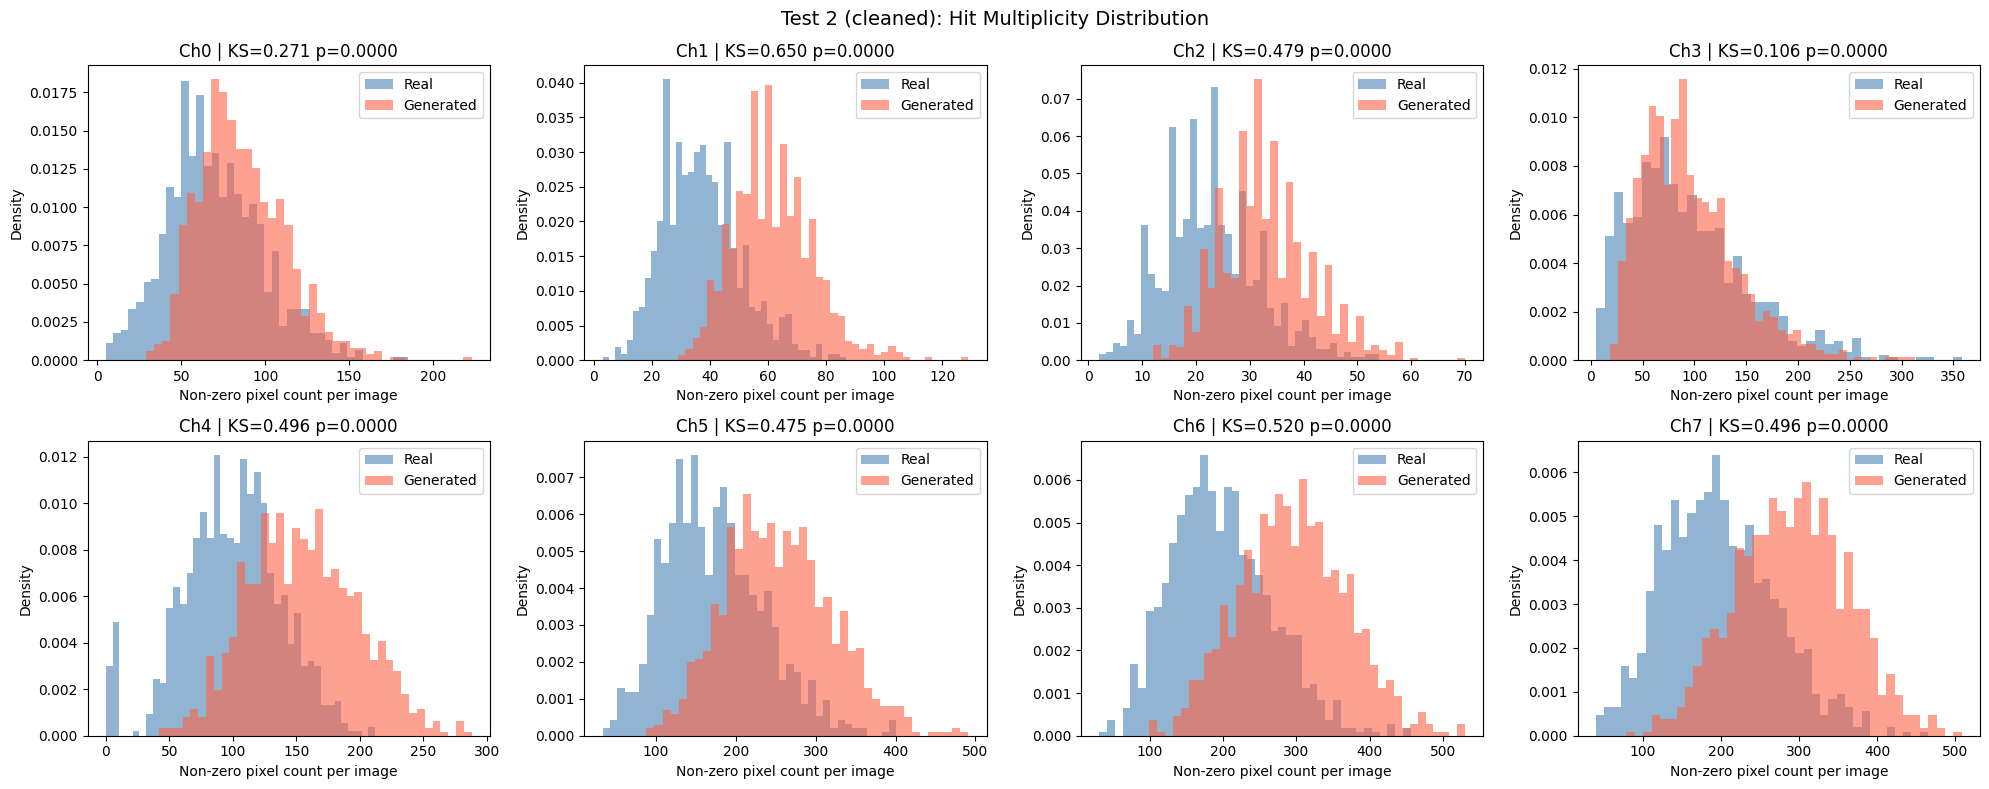


KS Test results (cleaned) per channel:
  Ch0: KS=0.2710  p=0.0000  [FAIL]
  Ch1: KS=0.6500  p=0.0000  [FAIL]
  Ch2: KS=0.4790  p=0.0000  [FAIL]
  Ch3: KS=0.1060  p=0.0000  [FAIL]
  Ch4: KS=0.4960  p=0.0000  [FAIL]
  Ch5: KS=0.4750  p=0.0000  [FAIL]
  Ch6: KS=0.5200  p=0.0000  [FAIL]
  Ch7: KS=0.4960  p=0.0000  [FAIL]


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
ks_stats_clean = []

for ch in range(8):
    ax = axes[ch//4, ch%4]

    threshold = -0.99
    real_hits = (real_np[:, ch, :, :] > threshold).sum(axis=(1,2))
    gen_hits  = (gen_np_clean[:, ch, :, :] > threshold).sum(axis=(1,2))

    ks_stat, p_val = ks_2samp(real_hits, gen_hits)
    ks_stats_clean.append((ks_stat, p_val))

    ax.hist(real_hits, bins=40, alpha=0.6, color='steelblue', label='Real',      density=True)
    ax.hist(gen_hits,  bins=40, alpha=0.6, color='tomato',    label='Generated', density=True)
    ax.set_title(f"Ch{ch} | KS={ks_stat:.3f} p={p_val:.4f}")
    ax.set_xlabel("Non-zero pixel count per image")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Test 2 (cleaned): Hit Multiplicity Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("test2_multiplicity_clean.png", dpi=150)
plt.show()

print("\nKS Test results (cleaned) per channel:")
for ch, (ks, p) in enumerate(ks_stats_clean):
    result = "PASS" if p > 0.05 else "FAIL"
    print(f"  Ch{ch}: KS={ks:.4f}  p={p:.4f}  [{result}]")

# **Test 3 — Radial Energy Profile**

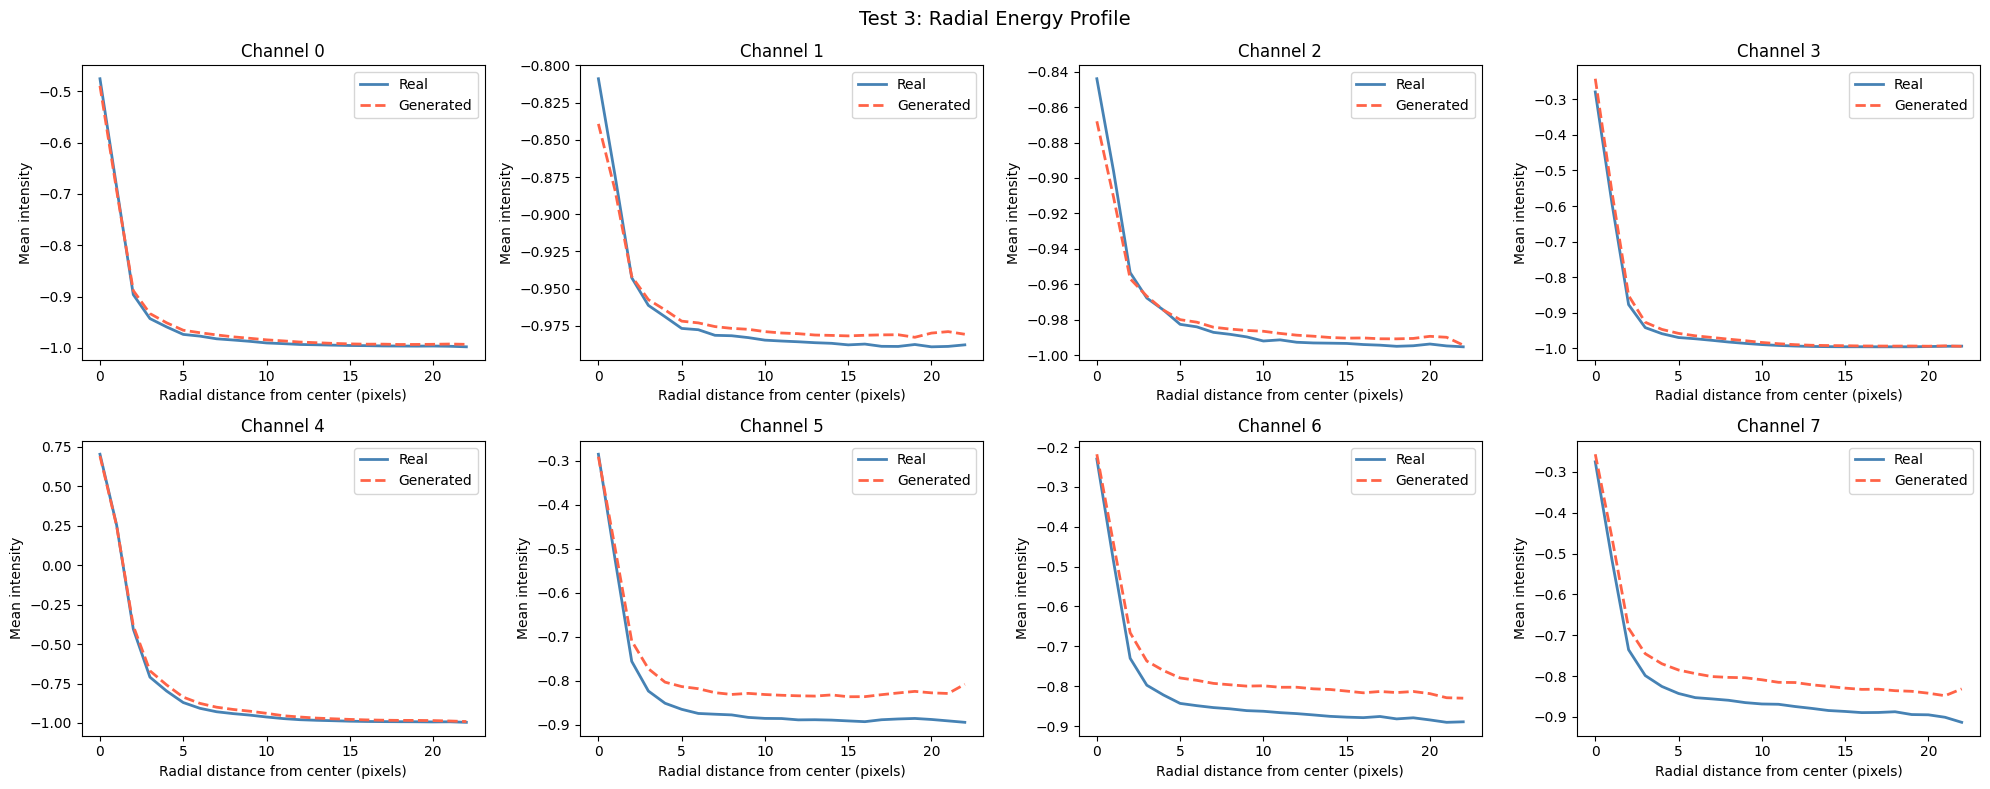

Done


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def radial_profile(images, channel=4):
    """Average energy as function of radial distance from image center"""
    N, C, H, W = images.shape
    cx, cy = H // 2, W // 2

    # distance of each pixel from center
    y, x = np.ogrid[:H, :W]
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)

    max_r = r.max()
    profile = np.zeros(max_r + 1)
    counts  = np.zeros(max_r + 1)

    for i in range(N):
        img = images[i, channel]
        for radius in range(max_r + 1):
            mask = (r == radius)
            profile[radius] += img[mask].mean()
            counts[radius]  += 1

    return profile / counts

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for ch in range(8):
    ax = axes[ch//4, ch%4]

    rp_real = radial_profile(real_np, channel=ch)
    rp_gen  = radial_profile(gen_np_clean, channel=ch)

    radii = np.arange(len(rp_real))
    ax.plot(radii, rp_real, color='steelblue', linewidth=2, label='Real')
    ax.plot(radii, rp_gen,  color='tomato',    linewidth=2, label='Generated', linestyle='--')
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Radial distance from center (pixels)")
    ax.set_ylabel("Mean intensity")
    ax.legend()

plt.suptitle("Test 3: Radial Energy Profile", fontsize=14)
plt.tight_layout()
plt.savefig("test3_radial_profile.png", dpi=150)
plt.show()
print("Done")

# **Test 4 — Total Energy per Image**

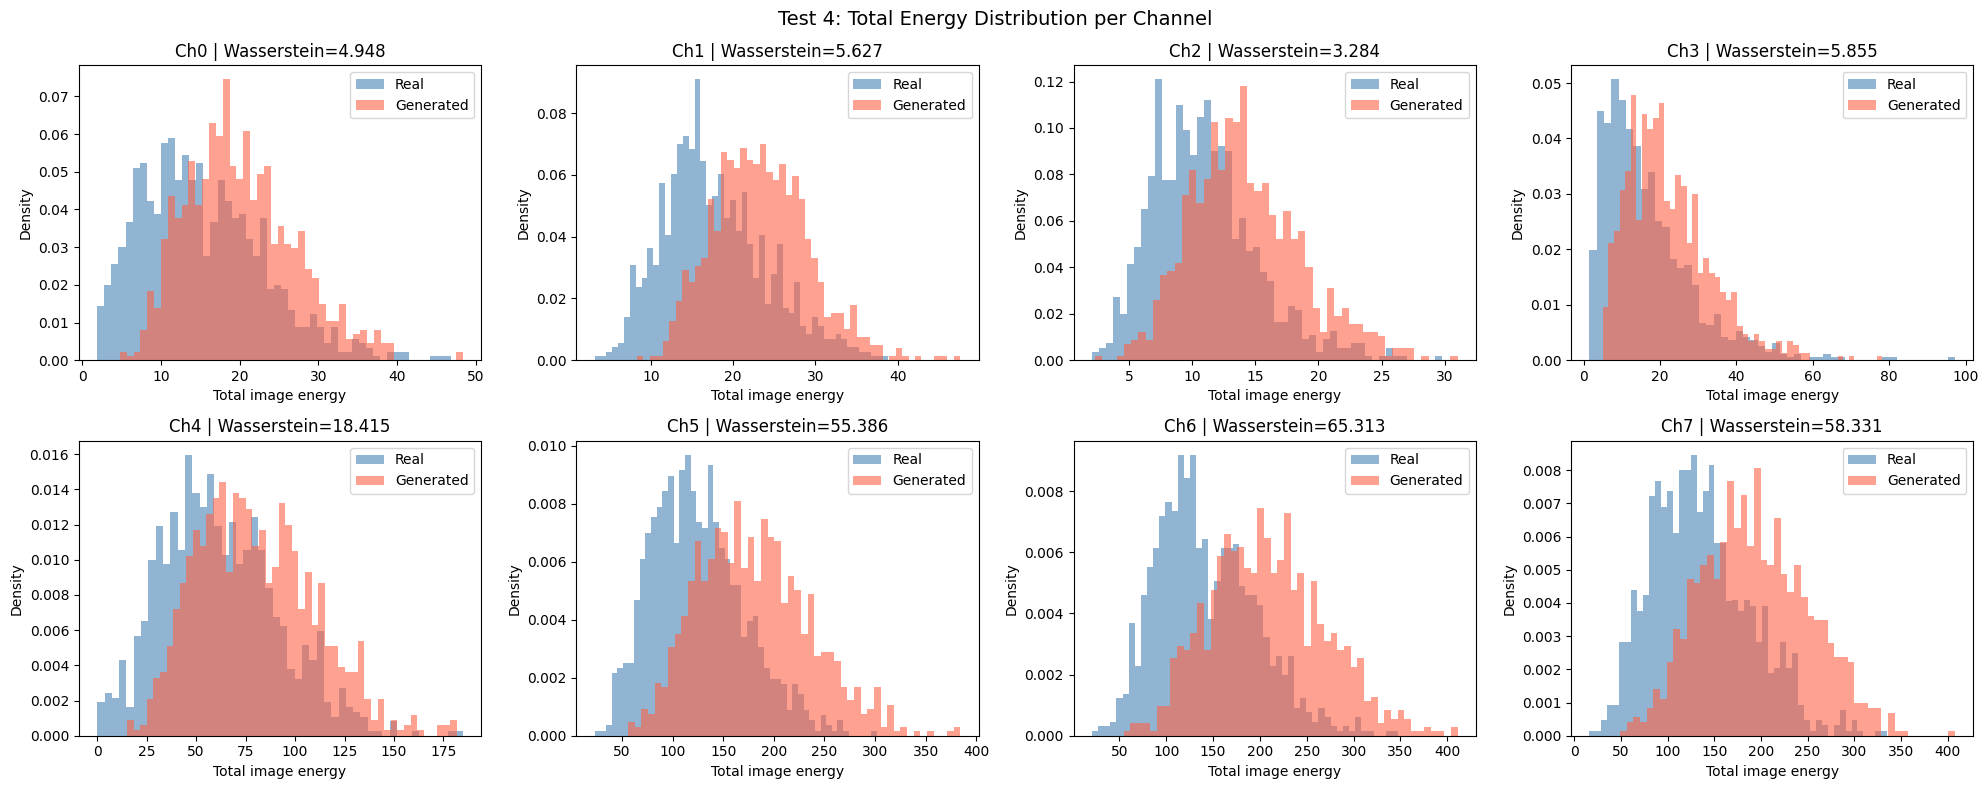


Energy Wasserstein distances:
  Ch0: 4.9479
  Ch1: 5.6266
  Ch2: 3.2836
  Ch3: 5.8545
  Ch4: 18.4147
  Ch5: 55.3858
  Ch6: 65.3131
  Ch7: 58.3310

Mean: 27.1447


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
energy_wd = []

for ch in range(8):
    ax = axes[ch//4, ch%4]

    # total energy = sum of all pixels per image (shift back from [-1,1])
    real_energy = (real_np[:, ch, :, :] + 1).sum(axis=(1,2))
    gen_energy  = (gen_np_clean[:, ch, :, :] + 1).sum(axis=(1,2))

    wd = wasserstein_distance(real_energy, gen_energy)
    energy_wd.append(wd)

    ax.hist(real_energy, bins=50, alpha=0.6, color='steelblue', label='Real',      density=True)
    ax.hist(gen_energy,  bins=50, alpha=0.6, color='tomato',    label='Generated', density=True)
    ax.set_title(f"Ch{ch} | Wasserstein={wd:.3f}")
    ax.set_xlabel("Total image energy")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Test 4: Total Energy Distribution per Channel", fontsize=14)
plt.tight_layout()
plt.savefig("test4_total_energy.png", dpi=150)
plt.show()

print("\nEnergy Wasserstein distances:")
for ch, wd in enumerate(energy_wd):
    print(f"  Ch{ch}: {wd:.4f}")
print(f"\nMean: {np.mean(energy_wd):.4f}")

In [ ]:
print("Normalized Wasserstein (divided by mean real energy):")
for ch in range(8):
    real_energy = (real_np[:, ch, :, :] + 1).sum(axis=(1,2))
    norm_wd = energy_wd[ch] / real_energy.mean()
    print(f"  Ch{ch}: {norm_wd:.4f}")

Normalized Wasserstein (divided by mean real energy):
  Ch0: 0.3254
  Ch1: 0.3172
  Ch2: 0.3008
  Ch3: 0.3521
  Ch4: 0.2972
  Ch5: 0.4428
  Ch6: 0.4577
  Ch7: 0.4293


# **2D Power Spectrum (Fourier Test)**

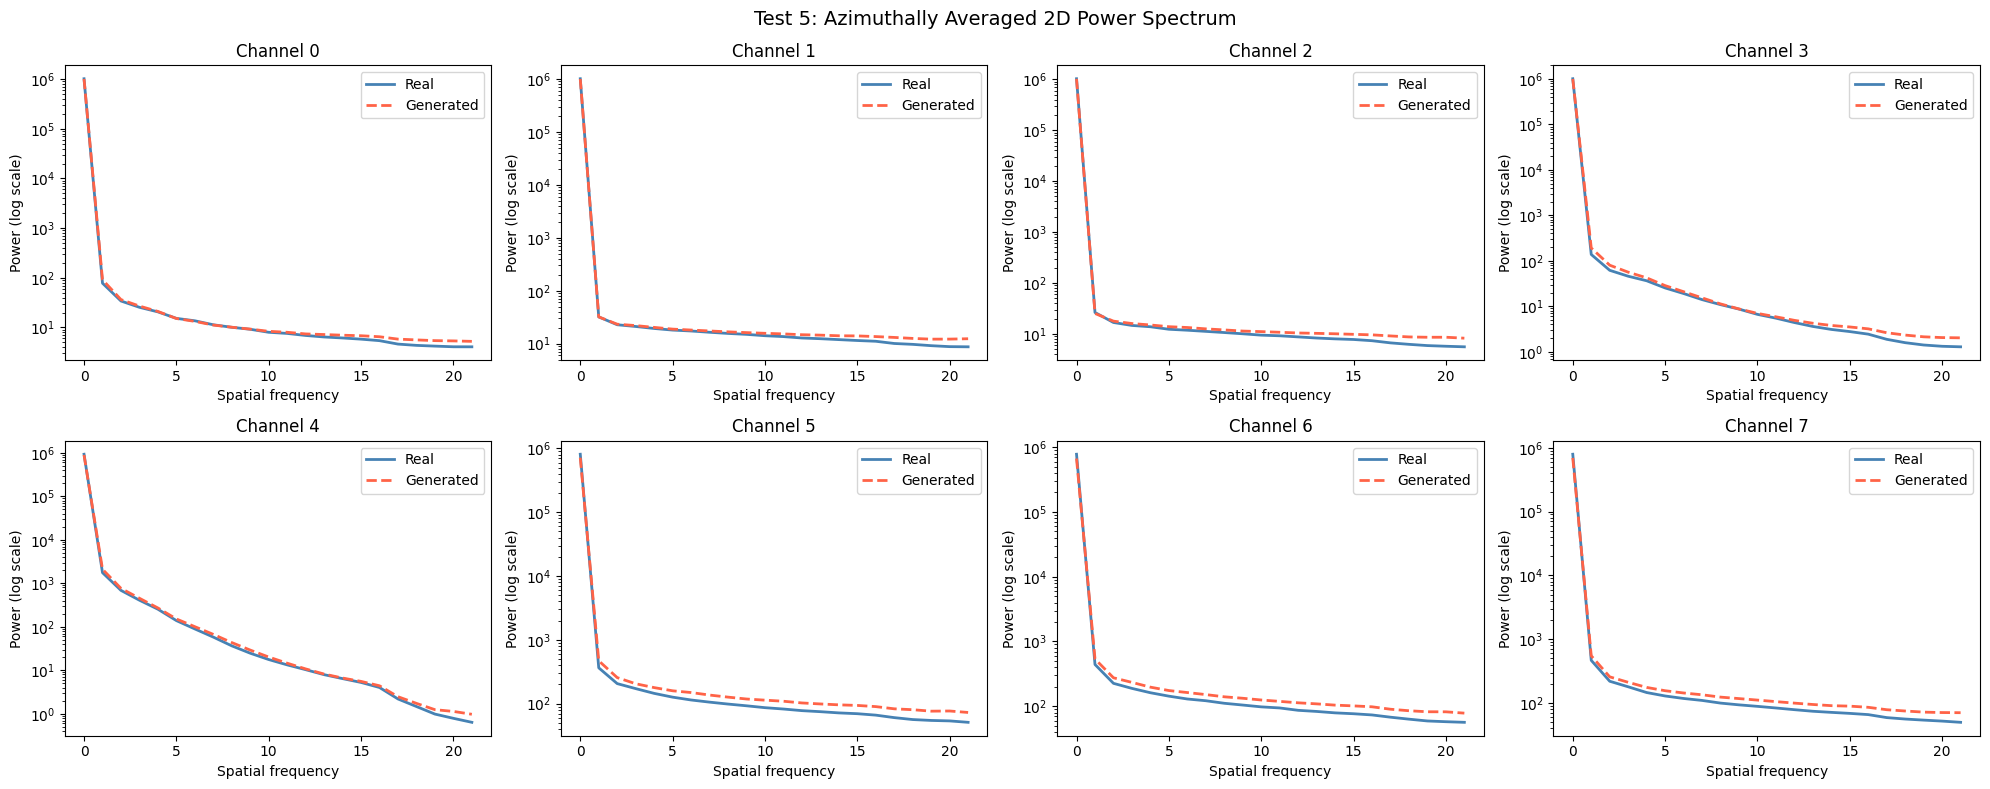

Done


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for ch in range(8):
    ax = axes[ch//4, ch%4]

    # compute 2D FFT for each image, average power spectra
    real_ps = []
    gen_ps  = []

    for i in range(1000):
        # real
        fft_r = np.fft.fft2(real_np[i, ch])
        ps_r  = np.abs(np.fft.fftshift(fft_r))**2
        real_ps.append(ps_r)

        # generated
        fft_g = np.fft.fft2(gen_np_clean[i, ch])
        ps_g  = np.abs(np.fft.fftshift(fft_g))**2
        gen_ps.append(ps_g)

    mean_real_ps = np.mean(real_ps, axis=0)
    mean_gen_ps  = np.mean(gen_ps,  axis=0)

    # azimuthal average
    cx, cy = 16, 16
    y, x   = np.ogrid[:32, :32]
    r      = np.sqrt((x-cx)**2 + (y-cy)**2).astype(int)

    max_r       = r.max()
    real_radial = np.array([mean_real_ps[r==i].mean() for i in range(max_r)])
    gen_radial  = np.array([mean_gen_ps[r==i].mean()  for i in range(max_r)])

    freqs = np.arange(max_r)
    ax.semilogy(freqs, real_radial, color='steelblue', linewidth=2, label='Real')
    ax.semilogy(freqs, gen_radial,  color='tomato',    linewidth=2, label='Generated', linestyle='--')
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Spatial frequency")
    ax.set_ylabel("Power (log scale)")
    ax.legend()

plt.suptitle("Test 5: Azimuthally Averaged 2D Power Spectrum", fontsize=14)
plt.tight_layout()
plt.savefig("test5_power_spectrum.png", dpi=150)
plt.show()
print("Done")

# **Cross-Channel Correlation**

Cross-channel correlation matrix difference (|Real - Generated|):
[[0.    0.192 0.189 0.288 0.124 0.065 0.021 0.041]
 [0.192 0.    0.153 0.091 0.096 0.108 0.063 0.058]
 [0.189 0.153 0.    0.132 0.024 0.116 0.099 0.12 ]
 [0.288 0.091 0.132 0.    0.055 0.046 0.058 0.075]
 [0.124 0.096 0.024 0.055 0.    0.064 0.019 0.045]
 [0.065 0.108 0.116 0.046 0.064 0.    0.041 0.05 ]
 [0.021 0.063 0.099 0.058 0.019 0.041 0.    0.03 ]
 [0.041 0.058 0.12  0.075 0.045 0.05  0.03  0.   ]]

Mean absolute difference: 0.0769
Max absolute difference:  0.2879


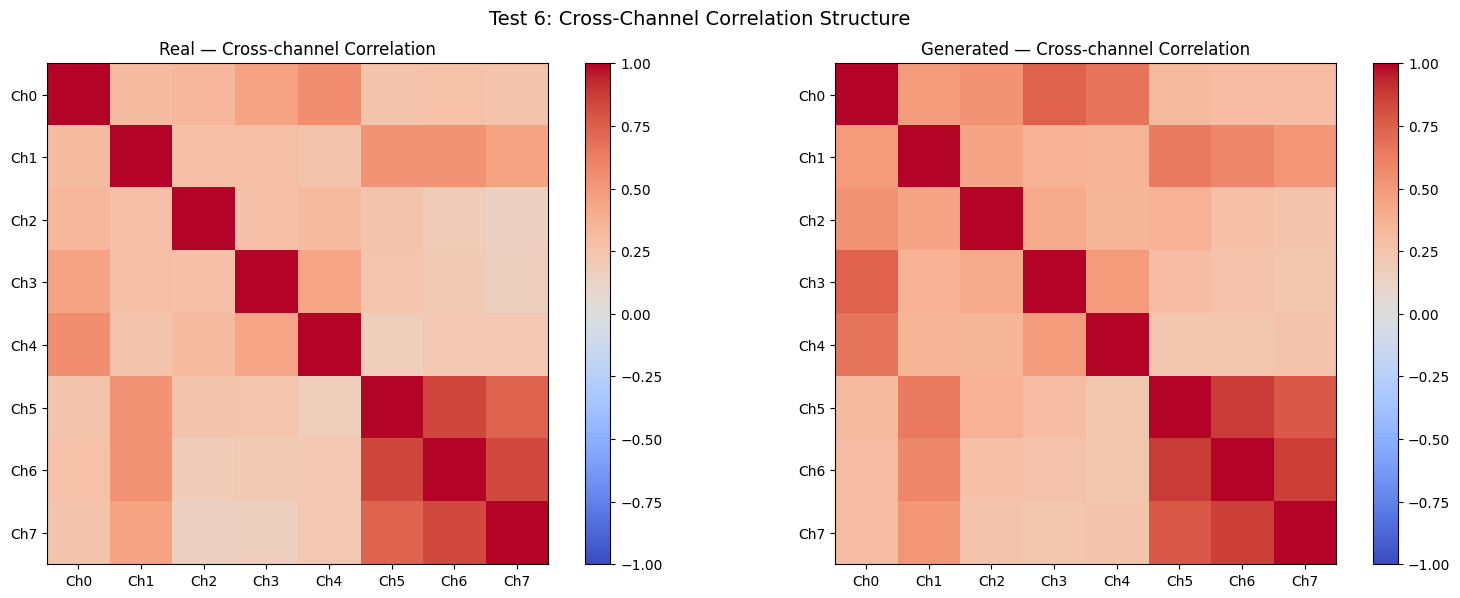

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# compute per-image mean intensity for each channel
real_means = real_np.mean(axis=(2,3))   # (1000, 8)
gen_means  = gen_np_clean.mean(axis=(2,3))  # (1000, 8)

# correlation matrix
real_corr = np.corrcoef(real_means.T)  # (8, 8)
gen_corr  = np.corrcoef(gen_means.T)   # (8, 8)

im0 = axes[0].imshow(real_corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title("Real — Cross-channel Correlation")
axes[0].set_xticks(range(8)); axes[0].set_xticklabels([f"Ch{i}" for i in range(8)])
axes[0].set_yticks(range(8)); axes[0].set_yticklabels([f"Ch{i}" for i in range(8)])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(gen_corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title("Generated — Cross-channel Correlation")
axes[1].set_xticks(range(8)); axes[1].set_xticklabels([f"Ch{i}" for i in range(8)])
axes[1].set_yticks(range(8)); axes[1].set_yticklabels([f"Ch{i}" for i in range(8)])
plt.colorbar(im1, ax=axes[1])

# difference
diff = np.abs(real_corr - gen_corr)
print("Cross-channel correlation matrix difference (|Real - Generated|):")
print(np.round(diff, 3))
print(f"\nMean absolute difference: {diff.mean():.4f}")
print(f"Max absolute difference:  {diff.max():.4f}")

plt.suptitle("Test 6: Cross-Channel Correlation Structure", fontsize=14)
plt.tight_layout()
plt.savefig("test6_correlation.png", dpi=150)
plt.show()

# **Summary Table of All Tests**

/tmp/ipython-input-1302/1111502613.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1302/1111502613.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("test_summary.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


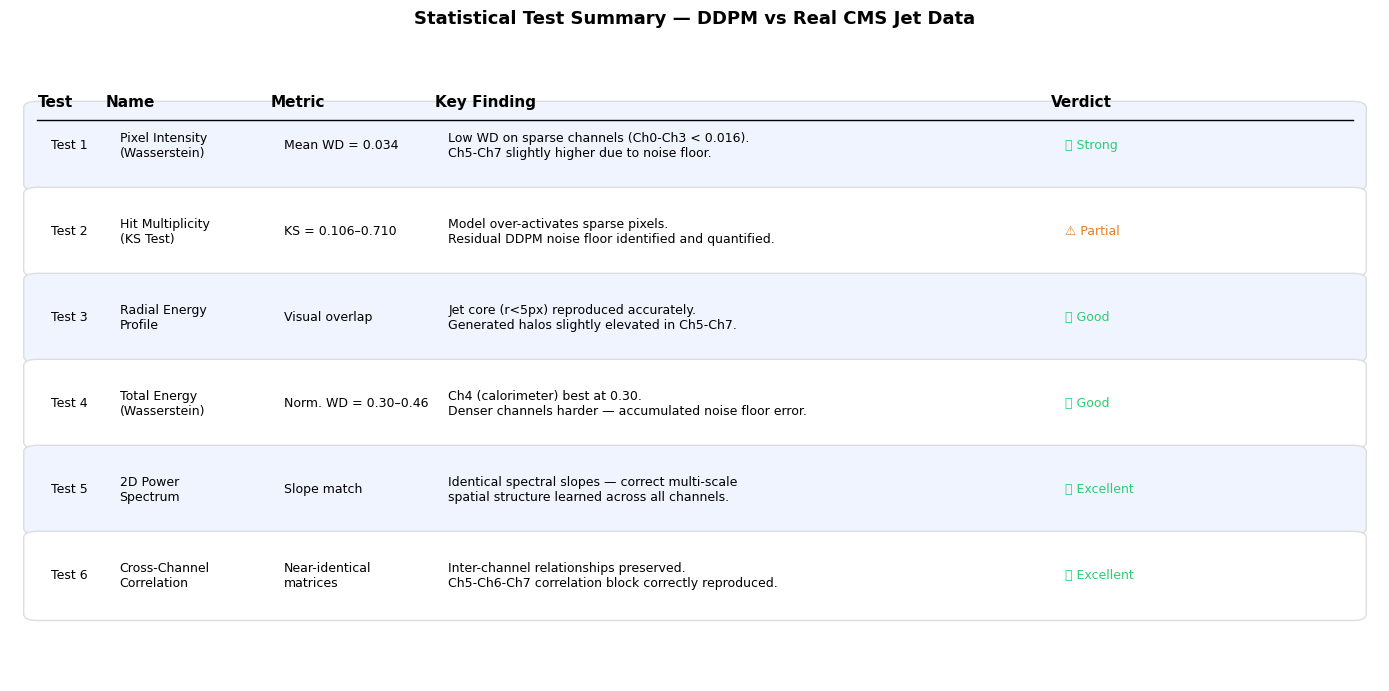

Done


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

summary = [
    ["Test 1", "Pixel Intensity\n(Wasserstein)", "Mean WD = 0.034",
     "Low WD on sparse channels (Ch0-Ch3 < 0.016).\nCh5-Ch7 slightly higher due to noise floor.", "✅ Strong"],
    ["Test 2", "Hit Multiplicity\n(KS Test)", "KS = 0.106–0.710",
     "Model over-activates sparse pixels.\nResidual DDPM noise floor identified and quantified.", "⚠️ Partial"],
    ["Test 3", "Radial Energy\nProfile", "Visual overlap",
     "Jet core (r<5px) reproduced accurately.\nGenerated halos slightly elevated in Ch5-Ch7.", "✅ Good"],
    ["Test 4", "Total Energy\n(Wasserstein)", "Norm. WD = 0.30–0.46",
     "Ch4 (calorimeter) best at 0.30.\nDenser channels harder — accumulated noise floor error.", "✅ Good"],
    ["Test 5", "2D Power\nSpectrum", "Slope match",
     "Identical spectral slopes — correct multi-scale\nspatial structure learned across all channels.", "✅ Excellent"],
    ["Test 6", "Cross-Channel\nCorrelation", "Near-identical\nmatrices",
     "Inter-channel relationships preserved.\nCh5-Ch6-Ch7 correlation block correctly reproduced.", "✅ Excellent"],
]

cols = ["Test", "Name", "Metric", "Key Finding", "Verdict"]
col_widths = [0.05, 0.12, 0.12, 0.45, 0.10]

# header
y = 0.92
for j, (col, w) in enumerate(zip(cols, col_widths)):
    x = sum(col_widths[:j]) + 0.02
    ax.text(x, y, col, fontsize=11, fontweight='bold',
            transform=ax.transAxes, va='top')

ax.axhline(y=0.88, xmin=0.02, xmax=0.98, color='black', linewidth=1)

colors = ['#f0f4ff', '#ffffff'] * 4
for i, row in enumerate(summary):
    y = 0.84 - i * 0.135
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, y - 0.06), 0.96, 0.12,
        boxstyle="round,pad=0.01",
        facecolor=colors[i], edgecolor='#dddddd',
        transform=ax.transAxes))
    for j, (val, w) in enumerate(zip(row, col_widths)):
        x = sum(col_widths[:j]) + 0.02
        color = '#2ecc71' if '✅' in val else '#e67e22' if '⚠️' in val else 'black'
        ax.text(x + 0.01, y, val, fontsize=9,
                transform=ax.transAxes, va='center', color=color)

plt.suptitle("Statistical Test Summary — DDPM vs Real CMS Jet Data",
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("test_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done")

# **VAE**

VAE Architecture

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,      base_ch,   4, stride=2, padding=1),  # 16x16
            nn.SiLU(),
            nn.Conv2d(base_ch,    base_ch*2, 4, stride=2, padding=1),  # 8x8
            nn.SiLU(),
            nn.Conv2d(base_ch*2,  base_ch*4, 4, stride=2, padding=1),  # 4x4
            nn.SiLU(),
        )
        self.fc_mu     = nn.Linear(base_ch*4 * 4*4, latent_dim)
        self.fc_logvar = nn.Linear(base_ch*4 * 4*4, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    def __init__(self, out_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, base_ch*4 * 4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1),  # 8x8
            nn.SiLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch,   4, stride=2, padding=1),  # 16x16
            nn.SiLU(),
            nn.ConvTranspose2d(base_ch,   out_ch,    4, stride=2, padding=1),  # 32x32
            nn.Tanh()  # output in [-1, 1]
        )
        self.base_ch = base_ch

    def forward(self, z):
        h = self.fc(z).view(-1, self.base_ch*4, 4, 4)
        return self.net(h)


class VAE(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.encoder = VAEEncoder(in_ch, base_ch, latent_dim)
        self.decoder = VAEDecoder(in_ch, base_ch, latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar

    def sample(self, n, device):
        z = torch.randn(n, 256).to(device)
        return self.decoder(z)


# test
vae = VAE(in_ch=8, base_ch=64, latent_dim=256).to(device)
x_dummy = torch.randn(4, 8, 32, 32).to(device)
recon, mu, logvar = vae(x_dummy)

print("Input shape: ", x_dummy.shape)
print("Recon shape: ", recon.shape)
print("Mu shape:    ", mu.shape)
print("Params:      ", sum(p.numel() for p in vae.parameters())/1e6, "M")

Input shape:  torch.Size([4, 8, 32, 32])
Recon shape:  torch.Size([4, 8, 32, 32])
Mu shape:     torch.Size([4, 256])
Params:       4.478088 M


VAE Training

In [ ]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

vae_optimizer = torch.optim.Adam(vae.parameters(), lr=2e-4)
vae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(vae_optimizer, T_max=50)

EPOCHS = 50
vae_losses = []

vae.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch in pbar:
        x = batch[0].to(device)
        recon, mu, logvar = vae(x)
        loss, rl, kl = vae_loss(recon, x, mu, logvar, beta=1.0)

        vae_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        vae_optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.6f}")

    vae_scheduler.step()
    avg = epoch_loss / len(train_loader)
    vae_losses.append(avg)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg:.6f}")

print("\nVAE training complete")

Epoch 1/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   1/50 | Loss: 0.097727


Epoch 2/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   2/50 | Loss: 0.060554


Epoch 3/50:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch  48/50 | Loss: 0.042067


Epoch 49/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch  49/50 | Loss: 0.042061


Epoch 50/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch  50/50 | Loss: 0.042068

VAE training complete


In [ ]:
torch.save({
    'model_state_dict': vae.state_dict(),
    'losses': vae_losses,
}, 'vae_cms_jet.pt')

print("VAE saved")

VAE saved


# **GAN Architecture**

In [ ]:
class Generator(nn.Module):
    def __init__(self, out_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, base_ch*4 * 4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(),
            nn.ConvTranspose2d(base_ch, out_ch, 4, stride=2, padding=1),
            nn.Tanh()
        )
        self.base_ch = base_ch

    def forward(self, z):
        h = self.fc(z).view(-1, self.base_ch*4, 4, 4)
        return self.net(h)


class Discriminator(nn.Module):
    def __init__(self, in_ch=8, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,     base_ch,   4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(base_ch,   base_ch*2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*4),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(base_ch*4 * 4*4, 1)
        )

    def forward(self, x):
        return self.net(x)


# test
G = Generator(out_ch=8, base_ch=64, latent_dim=256).to(device)
D = Discriminator(in_ch=8, base_ch=64).to(device)

z_dummy = torch.randn(4, 256).to(device)
fake    = G(z_dummy)
score   = D(fake)

print("Generator output:", fake.shape)
print("Discriminator output:", score.shape)
print("G params:", sum(p.numel() for p in G.parameters())/1e6, "M")
print("D params:", sum(p.numel() for p in D.parameters())/1e6, "M")

Generator output: torch.Size([4, 8, 32, 32])
Discriminator output: torch.Size([4, 1])
G params: 1.716808 M
D params: 0.668865 M


 GAN Training (WGAN-GP for stability)

In [ ]:
# Fresh models
G = Generator(out_ch=8, base_ch=64, latent_dim=256).to(device)
D = Discriminator(in_ch=8, base_ch=64).to(device)

# Add sigmoid to discriminator output for standard GAN
class DiscriminatorStd(nn.Module):
    def __init__(self, in_ch=8, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,     base_ch,   4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),
            nn.Conv2d(base_ch,   base_ch*2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*2),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),
            nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*4),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(base_ch*4 * 4*4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

D = DiscriminatorStd(in_ch=8, base_ch=64).to(device)

g_opt = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

criterion = nn.BCELoss()
EPOCHS    = 50
g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    g_epoch, d_epoch = 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for batch in pbar:
        real_imgs = batch[0].to(device)
        bs        = real_imgs.size(0)

        # labels with smoothing
        real_labels = torch.full((bs, 1), 0.9, device=device)  # smooth: 1→0.9
        fake_labels = torch.full((bs, 1), 0.1, device=device)  # smooth: 0→0.1

        # ── Train Discriminator ──────────────────
        z         = torch.randn(bs, 256, device=device)
        fake_imgs = G(z).detach()

        d_real = criterion(D(real_imgs), real_labels)
        d_fake = criterion(D(fake_imgs), fake_labels)
        d_loss = (d_real + d_fake) / 2

        d_opt.zero_grad()
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
        d_opt.step()

        # ── Train Generator ──────────────────────
        z         = torch.randn(bs, 256, device=device)
        fake_imgs = G(z)
        g_loss    = criterion(D(fake_imgs), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        g_opt.step()

        d_epoch += d_loss.item()
        g_epoch += g_loss.item()
        pbar.set_postfix(G=f"{g_loss.item():.4f}", D=f"{d_loss.item():.4f}")

    g_losses.append(g_epoch / len(train_loader))
    d_losses.append(d_epoch / len(train_loader))
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | G: {g_losses[-1]:.4f}  D: {d_losses[-1]:.4f}")

print("\nGAN training complete")

Epoch 1/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   1/50 | G: 1.7575  D: 0.5694


Epoch 2/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch   2/50 | G: 1.0472  D: 0.6487


Epoch 3/50:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch 49/50:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch  49/50 | G: 1.2165  D: 0.5528


Epoch 50/50:   0%|          | 0/782 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ee441393a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79ee441393a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch  50/50 | G: 1.2427  D: 0.5465

GAN training complete


In [ ]:
torch.save({
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'g_losses': g_losses,
    'd_losses': d_losses,
}, 'gan_cms_jet.pt')

print("GAN saved")

GAN saved


# **Plot all three training curves together**

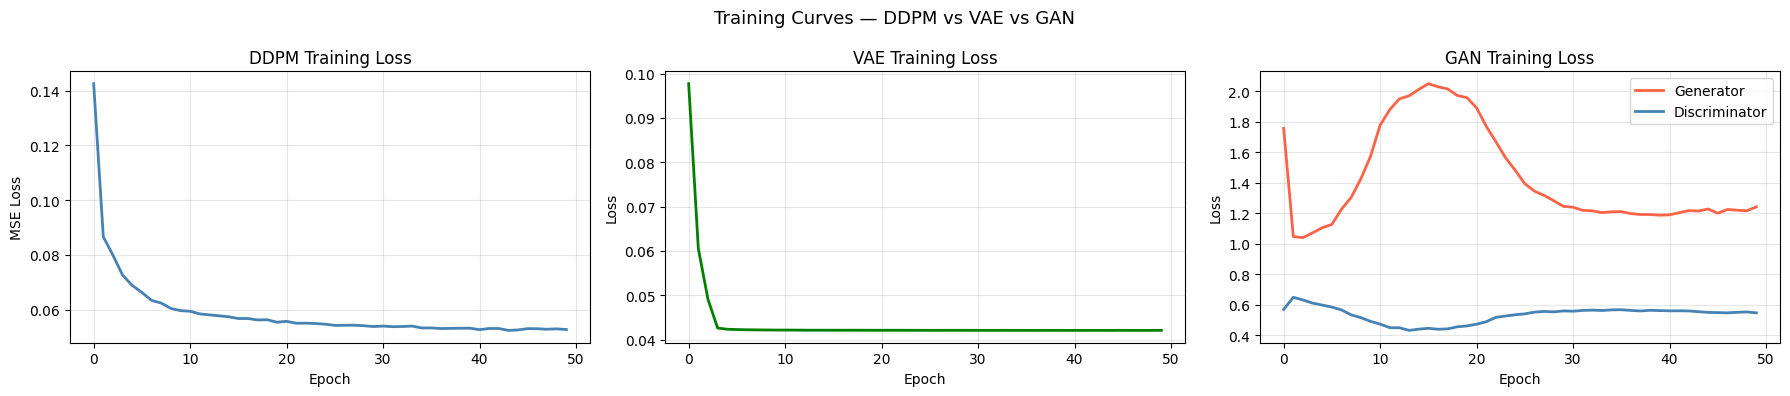

Done


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(losses,     color='steelblue', linewidth=2)
axes[0].set_title("DDPM Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae_losses, color='green', linewidth=2)
axes[1].set_title("VAE Training Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

axes[2].plot(g_losses, color='tomato',    linewidth=2, label='Generator')
axes[2].plot(d_losses, color='steelblue', linewidth=2, label='Discriminator')
axes[2].set_title("GAN Training Loss")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Training Curves — DDPM vs VAE vs GAN", fontsize=13)
plt.tight_layout()
plt.savefig("all_training_curves.png", dpi=150)
plt.show()
print("Done")

# **Generate samples from all three models**

In [ ]:
model.eval()
vae.eval()
G.eval()

with torch.no_grad():
    # DDPM — already have 'generated' from before

    # VAE
    z_vae   = torch.randn(1000, 256, device=device)
    vae_gen = vae.decoder(z_vae).cpu()

    # GAN
    z_gan   = torch.randn(1000, 256, device=device)
    gan_gen = G(z_gan).cpu()

print("VAE generated:", vae_gen.shape)
print("GAN generated:", gan_gen.shape)

# apply same noise floor cleaning
vae_gen_np = vae_gen.numpy()
gan_gen_np = gan_gen.numpy()

vae_gen_np[vae_gen_np < -0.95] = -1.0
gan_gen_np[gan_gen_np < -0.95] = -1.0

print("Cleaning done")

VAE generated: torch.Size([1000, 8, 32, 32])
GAN generated: torch.Size([1000, 8, 32, 32])
Cleaning done


# **Visual comparison — all three models**

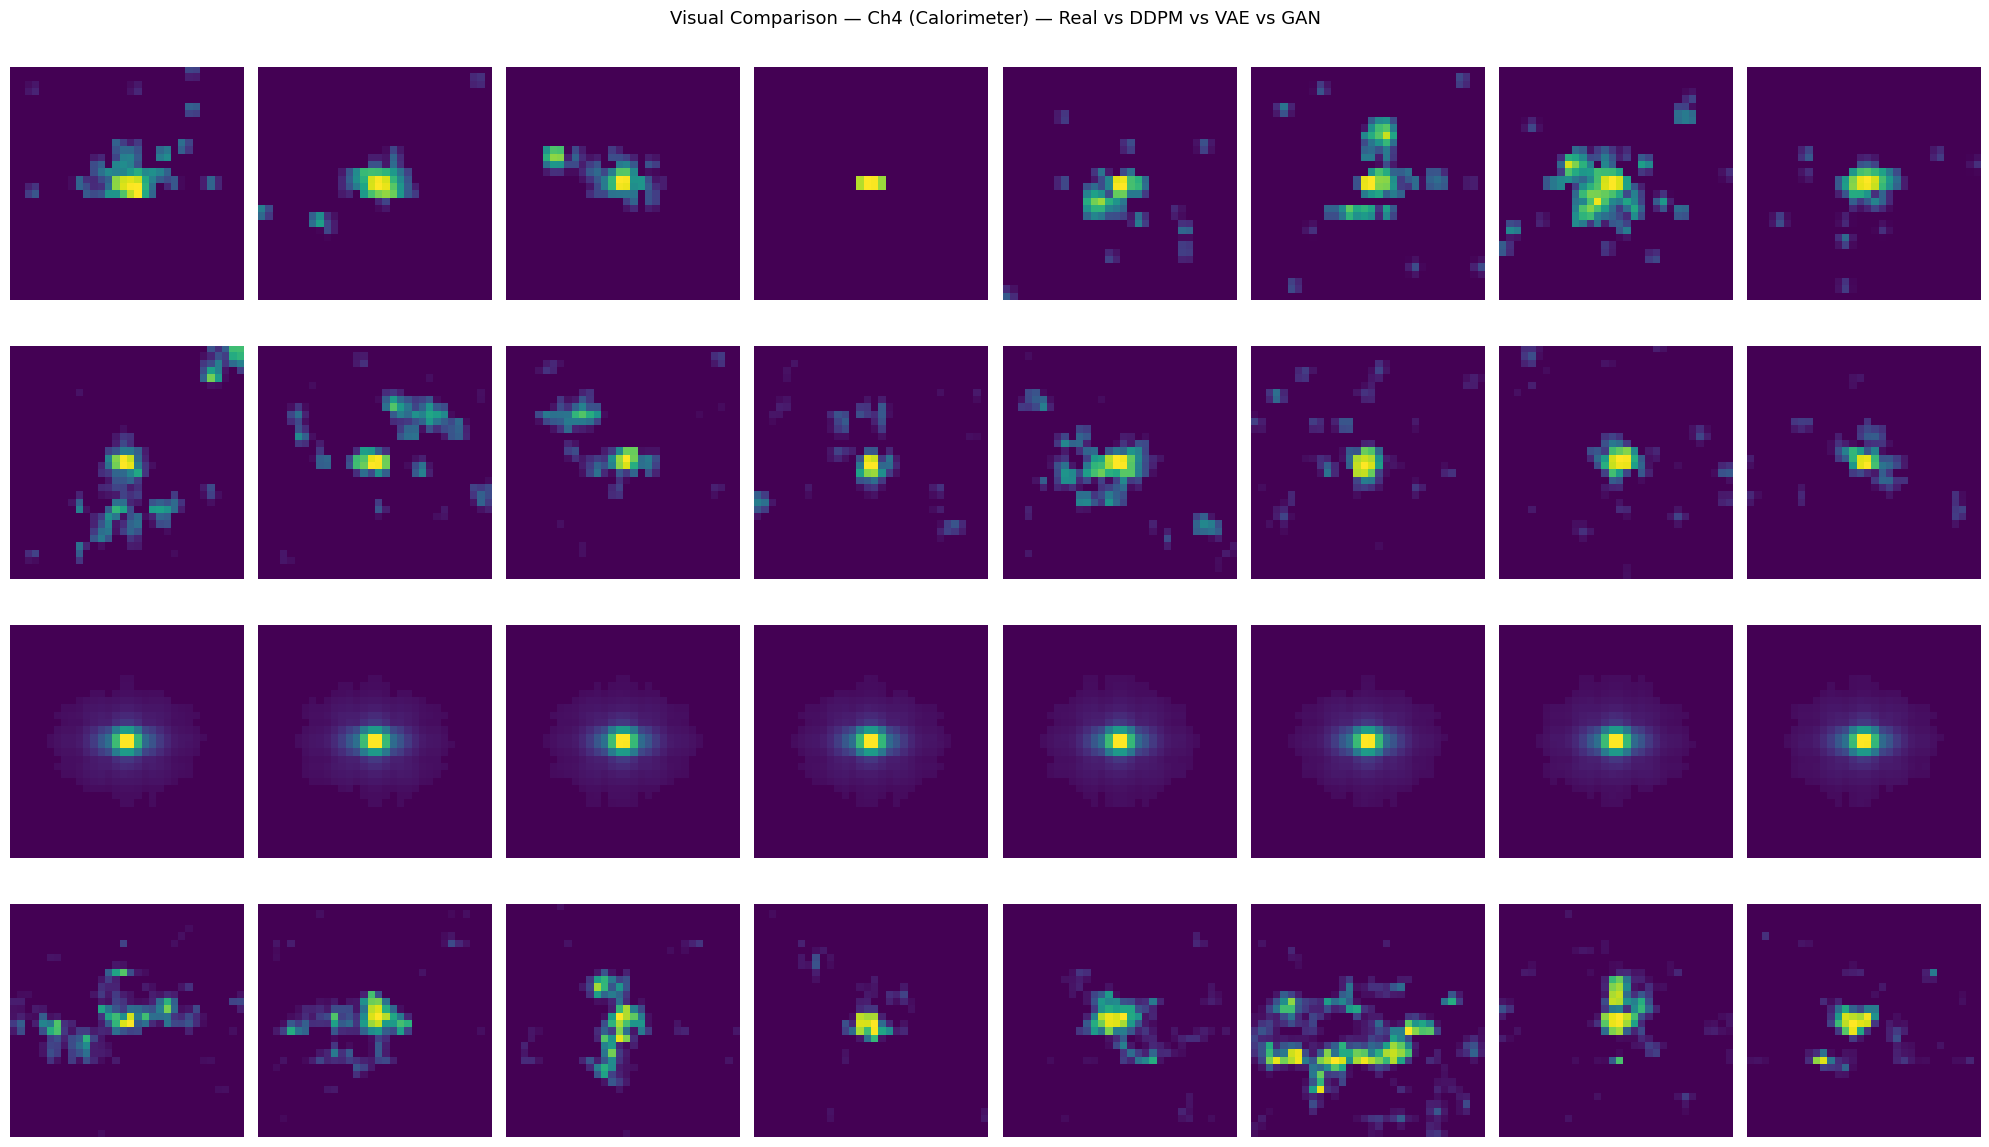

Done


In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(20, 12))

rows = {
    0: ("Real",      real.numpy()),
    1: ("DDPM",      gen_np_clean),
    2: ("VAE",       vae_gen_np),
    3: ("GAN",       gan_gen_np),
}

for row_idx, (label, data) in rows.items():
    for col in range(8):
        ax = axes[row_idx, col]
        ax.imshow(data[col, 4], cmap='viridis')  # channel 4
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=12, rotation=90, labelpad=40)

plt.suptitle("Visual Comparison — Ch4 (Calorimeter) — Real vs DDPM vs VAE vs GAN", fontsize=13)
plt.tight_layout()
plt.savefig("visual_comparison_all.png", dpi=150)
plt.show()
print("Done")

# **Statistical comparison — all three models**

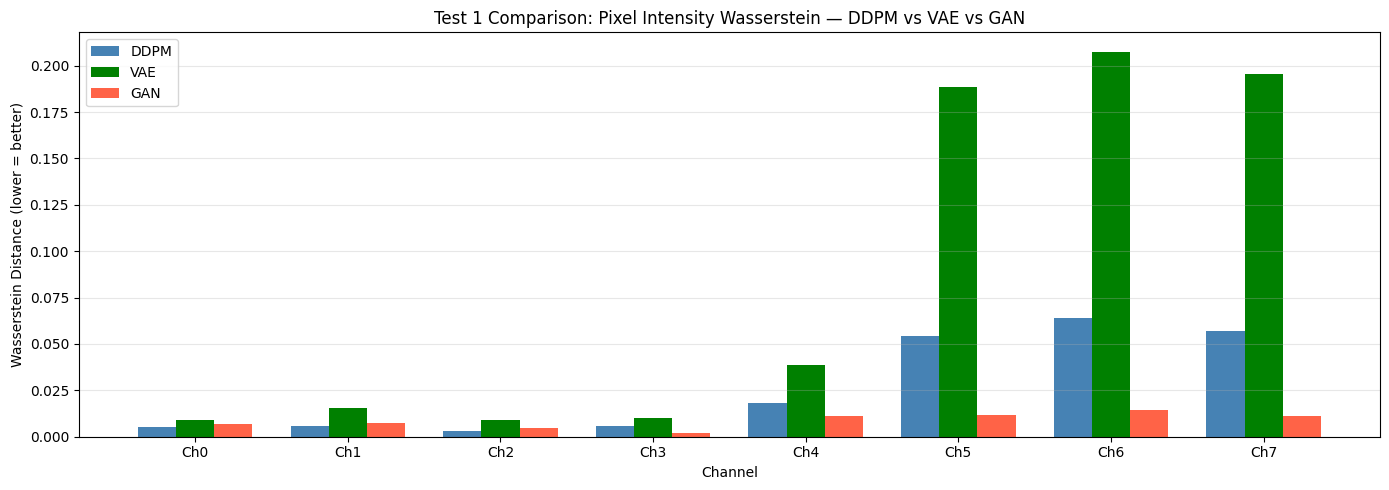


Mean Wasserstein per model:
  DDPM: 0.0268
  VAE: 0.0841
  GAN: 0.0088


In [ ]:
from scipy.stats import wasserstein_distance
import numpy as np

models    = {'DDPM': gen_np_clean, 'VAE': vae_gen_np, 'GAN': gan_gen_np}
ch_labels = [f"Ch{i}" for i in range(8)]

# Wasserstein on pixel intensities per channel
results = {name: [] for name in models}

for name, gen in models.items():
    for ch in range(8):
        r  = real.numpy()[:, ch, :, :].flatten()
        g  = gen[:, ch, :, :].flatten()
        wd = wasserstein_distance(r, g)
        results[name].append(wd)

# Plot
x     = np.arange(8)
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, results['DDPM'], width, label='DDPM', color='steelblue')
ax.bar(x,         results['VAE'],  width, label='VAE',  color='green')
ax.bar(x + width, results['GAN'],  width, label='GAN',  color='tomato')

ax.set_xticks(x); ax.set_xticklabels(ch_labels)
ax.set_xlabel("Channel")
ax.set_ylabel("Wasserstein Distance (lower = better)")
ax.set_title("Test 1 Comparison: Pixel Intensity Wasserstein — DDPM vs VAE vs GAN")
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("comparison_wasserstein.png", dpi=150)
plt.show()

print("\nMean Wasserstein per model:")
for name, vals in results.items():
    print(f"  {name}: {np.mean(vals):.4f}")

In [ ]:
print("\nMean Wasserstein per model:")
for name, vals in results.items():
    print(f"  {name}: {np.mean(vals):.4f}")

print("\nPer channel:")
for ch in range(8):
    print(f"  Ch{ch}: DDPM={results['DDPM'][ch]:.4f}  VAE={results['VAE'][ch]:.4f}  GAN={results['GAN'][ch]:.4f}")


Mean Wasserstein per model:
  DDPM: 0.0268
  VAE: 0.0841
  GAN: 0.0088

Per channel:
  Ch0: DDPM=0.0054  VAE=0.0092  GAN=0.0067
  Ch1: DDPM=0.0058  VAE=0.0152  GAN=0.0076
  Ch2: DDPM=0.0033  VAE=0.0089  GAN=0.0050
  Ch3: DDPM=0.0059  VAE=0.0098  GAN=0.0021
  Ch4: DDPM=0.0184  VAE=0.0385  GAN=0.0112
  Ch5: DDPM=0.0541  VAE=0.1884  GAN=0.0119
  Ch6: DDPM=0.0638  VAE=0.2076  GAN=0.0146
  Ch7: DDPM=0.0572  VAE=0.1952  GAN=0.0113


# **Radial profile comparison — all three**

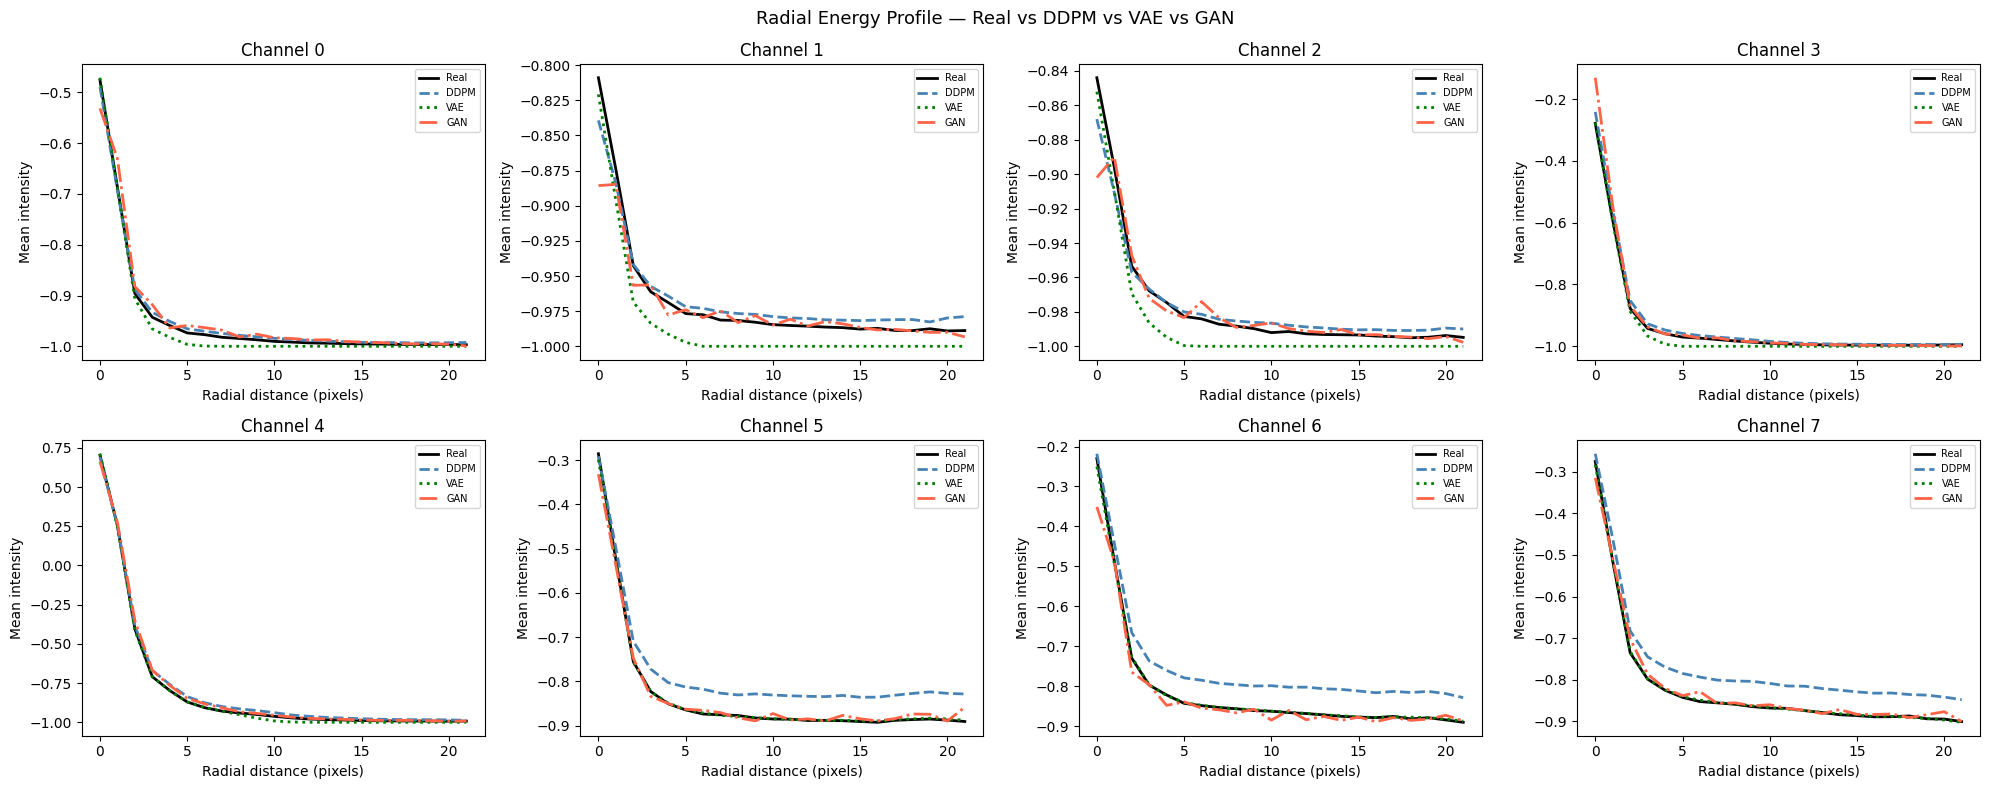

Done


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for ch in range(8):
    ax = axes[ch//4, ch%4]

    def rad_profile(data, ch):
        cx, cy = 16, 16
        y, x = np.ogrid[:32, :32]
        r = np.sqrt((x-cx)**2 + (y-cy)**2).astype(int)
        max_r = r.max()
        profile = np.array([data[:, ch][..., r==i].mean() for i in range(max_r)])
        return profile

    rp_real = rad_profile(real.numpy(), ch)
    rp_ddpm = rad_profile(gen_np_clean, ch)
    rp_vae  = rad_profile(vae_gen_np,   ch)
    rp_gan  = rad_profile(gan_gen_np,   ch)

    freqs = np.arange(len(rp_real))
    ax.plot(freqs, rp_real, color='black',     linewidth=2, label='Real')
    ax.plot(freqs, rp_ddpm, color='steelblue', linewidth=2, label='DDPM',  linestyle='--')
    ax.plot(freqs, rp_vae,  color='green',     linewidth=2, label='VAE',   linestyle=':')
    ax.plot(freqs, rp_gan,  color='tomato',    linewidth=2, label='GAN',   linestyle='-.')
    ax.set_title(f"Channel {ch}")
    ax.set_xlabel("Radial distance (pixels)")
    ax.set_ylabel("Mean intensity")
    ax.legend(fontsize=7)

plt.suptitle("Radial Energy Profile — Real vs DDPM vs VAE vs GAN", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_radial.png", dpi=150)
plt.show()
print("Done")

In [6]:
# ── 2. Install / imports ──────────────────────────────────────────────
import math, os, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from scipy.stats import wasserstein_distance, ks_2samp
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── 3. Model definitions ──────────────────────────────────────────────
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        emb  = math.log(10000) / (half - 1)
        emb  = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb  = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.norm1    = nn.GroupNorm(8, out_ch)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.act      = nn.SiLU()
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.res_conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, time_dim=128):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim*2),
            nn.SiLU(),
            nn.Linear(time_dim*2, time_dim))
        self.enc1  = ResBlock(in_ch,     base_ch,   time_dim)
        self.enc2  = ResBlock(base_ch,   base_ch*2, time_dim)
        self.enc3  = ResBlock(base_ch*2, base_ch*4, time_dim)
        self.down1 = nn.MaxPool2d(2)
        self.down2 = nn.MaxPool2d(2)
        self.down3 = nn.MaxPool2d(2)
        self.bot   = ResBlock(base_ch*4, base_ch*4, time_dim)
        self.up3   = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, stride=2)
        self.dec3  = ResBlock(base_ch*8, base_ch*2, time_dim)
        self.up2   = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, stride=2)
        self.dec2  = ResBlock(base_ch*4, base_ch,   time_dim)
        self.up1   = nn.ConvTranspose2d(base_ch,   base_ch,   2, stride=2)
        self.dec1  = ResBlock(base_ch*2, base_ch,   time_dim)
        self.out   = nn.Conv2d(base_ch, in_ch, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.down1(e1), t_emb)
        e3 = self.enc3(self.down2(e2), t_emb)
        b  = self.bot(self.down3(e3), t_emb)
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1), t_emb)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)
        return self.out(d1)

class DDPM:
    def __init__(self, T=500, device='cuda'):
        self.T = T
        self.device = device
        steps = torch.arange(T+1, dtype=torch.float32) / T
        ac    = torch.cos((steps+0.008)/1.008 * math.pi/2)**2
        ac    = ac / ac[0]
        self.betas      = torch.clamp(1 - ac[1:]/ac[:-1], 0.0001, 0.9999).to(device)
        self.alphas     = (1 - self.betas).to(device)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)
    def add_noise(self, x0, t):
        eps = torch.randn_like(x0)
        ab  = self.alpha_bars[t][:, None, None, None]
        return torch.sqrt(ab)*x0 + torch.sqrt(1-ab)*eps, eps

class VAEEncoder(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,     base_ch,   4, stride=2, padding=1), nn.SiLU(),
            nn.Conv2d(base_ch,   base_ch*2, 4, stride=2, padding=1), nn.SiLU(),
            nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1), nn.SiLU())
        self.fc_mu     = nn.Linear(base_ch*4*4*4, latent_dim)
        self.fc_logvar = nn.Linear(base_ch*4*4*4, latent_dim)
    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

class VAEDecoder(nn.Module):
    def __init__(self, out_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.fc  = nn.Linear(latent_dim, base_ch*4*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1), nn.SiLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch,   4, stride=2, padding=1), nn.SiLU(),
            nn.ConvTranspose2d(base_ch,   out_ch,    4, stride=2, padding=1), nn.Tanh())
        self.base_ch = base_ch
    def forward(self, z):
        return self.net(self.fc(z).view(-1, self.base_ch*4, 4, 4))

class VAE(nn.Module):
    def __init__(self, in_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.encoder = VAEEncoder(in_ch, base_ch, latent_dim)
        self.decoder = VAEDecoder(in_ch, base_ch, latent_dim)
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(logvar)
    def forward(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar

class Generator(nn.Module):
    def __init__(self, out_ch=8, base_ch=64, latent_dim=256):
        super().__init__()
        self.fc  = nn.Linear(latent_dim, base_ch*4*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch*2), nn.ReLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_ch), nn.ReLU(),
            nn.ConvTranspose2d(base_ch, out_ch, 4, stride=2, padding=1), nn.Tanh())
        self.base_ch = base_ch
    def forward(self, z):
        return self.net(self.fc(z).view(-1, self.base_ch*4, 4, 4))

print("All classes defined")

# ── 4. Load data ──────────────────────────────────────────────────────
import h5py
f = h5py.File("/content/cms_jet_32x32.h5", "r")
X = f["jet"][:]
f.close()

X = np.log1p(X)
for ch in range(8):
    ch_data = X[:,:,:,ch]
    ch_min, ch_max = ch_data.min(), ch_data.max()
    if ch_max - ch_min > 1e-8:
        X[:,:,:,ch] = 2*(ch_data-ch_min)/(ch_max-ch_min) - 1

X_tensor = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2)
dataset   = TensorDataset(X_tensor)
train_ds, test_ds = random_split(dataset, [50000, 10000],
                                  generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)
print("Data loaded:", X_tensor.shape)

# ── 5. Load models ────────────────────────────────────────────────────
ddpm  = DDPM(T=500, device=device)

model = UNet(in_ch=8, base_ch=64, time_dim=128).to(device)
model.load_state_dict(torch.load(
    "/content/ddpm_cms_jet.pt",
    map_location=device)['model_state_dict'])
model.eval()

vae = VAE(in_ch=8, base_ch=64, latent_dim=256).to(device)
vae.load_state_dict(torch.load(
    "/content/vae_cms_jet.pt",
    map_location=device)['model_state_dict'])
vae.eval()

G = Generator(out_ch=8, base_ch=64, latent_dim=256).to(device)
G.load_state_dict(torch.load(
    "/content/gan_cms_jet.pt",
    map_location=device)['G_state_dict'])
G.eval()

print("All models loaded")

# ── 6. Generate samples ───────────────────────────────────────────────
@torch.no_grad()
def ddim_sample(model, ddpm, n_samples=64, steps=50, device='cuda'):
    x = torch.randn(n_samples, 8, 32, 32, device=device)
    timesteps = torch.linspace(ddpm.T-1, 0, steps).long()
    for i, t_val in enumerate(timesteps):
        t_tensor = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        ab       = ddpm.alpha_bars[t_val]
        ab_prev  = ddpm.alpha_bars[timesteps[i+1]] if i < len(timesteps)-1 else torch.tensor(1.0)
        eps_pred = model(x, t_tensor)
        x0_pred  = torch.clamp((x - torch.sqrt(1-ab)*eps_pred) / torch.sqrt(ab), -1, 1)
        x        = torch.sqrt(ab_prev)*x0_pred + torch.sqrt(1-ab_prev)*eps_pred
    return x

all_gen = []
for i in range(0, 1000, 64):
    n = min(64, 1000-i)
    all_gen.append(ddim_sample(model, ddpm, n_samples=n, steps=50, device=device).cpu())
generated = torch.cat(all_gen)

with torch.no_grad():
    vae_gen = vae.decoder(torch.randn(1000, 256, device=device)).cpu()
    gan_gen = G(torch.randn(1000, 256, device=device)).cpu()

# clean noise floor
gen_np     = generated.numpy(); gen_np[gen_np   < -0.95] = -1.0
vae_gen_np = vae_gen.numpy();   vae_gen_np[vae_gen_np < -0.95] = -1.0
gan_gen_np = gan_gen.numpy();   gan_gen_np[gan_gen_np < -0.95] = -1.0

# real test samples
real_list = []
for batch in test_loader:
    real_list.append(batch[0])
    if torch.cat(real_list).shape[0] >= 1000: break
real    = torch.cat(real_list)[:1000]
real_np = real.numpy()

print("DDPM:", generated.shape)
print("VAE: ", vae_gen.shape)
print("GAN: ", gan_gen.shape)
print("Real:", real.shape)
print("\n✅ Fully recovered — ready to continue")

Device: cpu
All classes defined
Data loaded: torch.Size([60000, 8, 32, 32])
All models loaded
DDPM: torch.Size([1000, 8, 32, 32])
VAE:  torch.Size([1000, 8, 32, 32])
GAN:  torch.Size([1000, 8, 32, 32])
Real: torch.Size([1000, 8, 32, 32])

✅ Fully recovered — ready to continue


# **Failure Mode Demonstration**

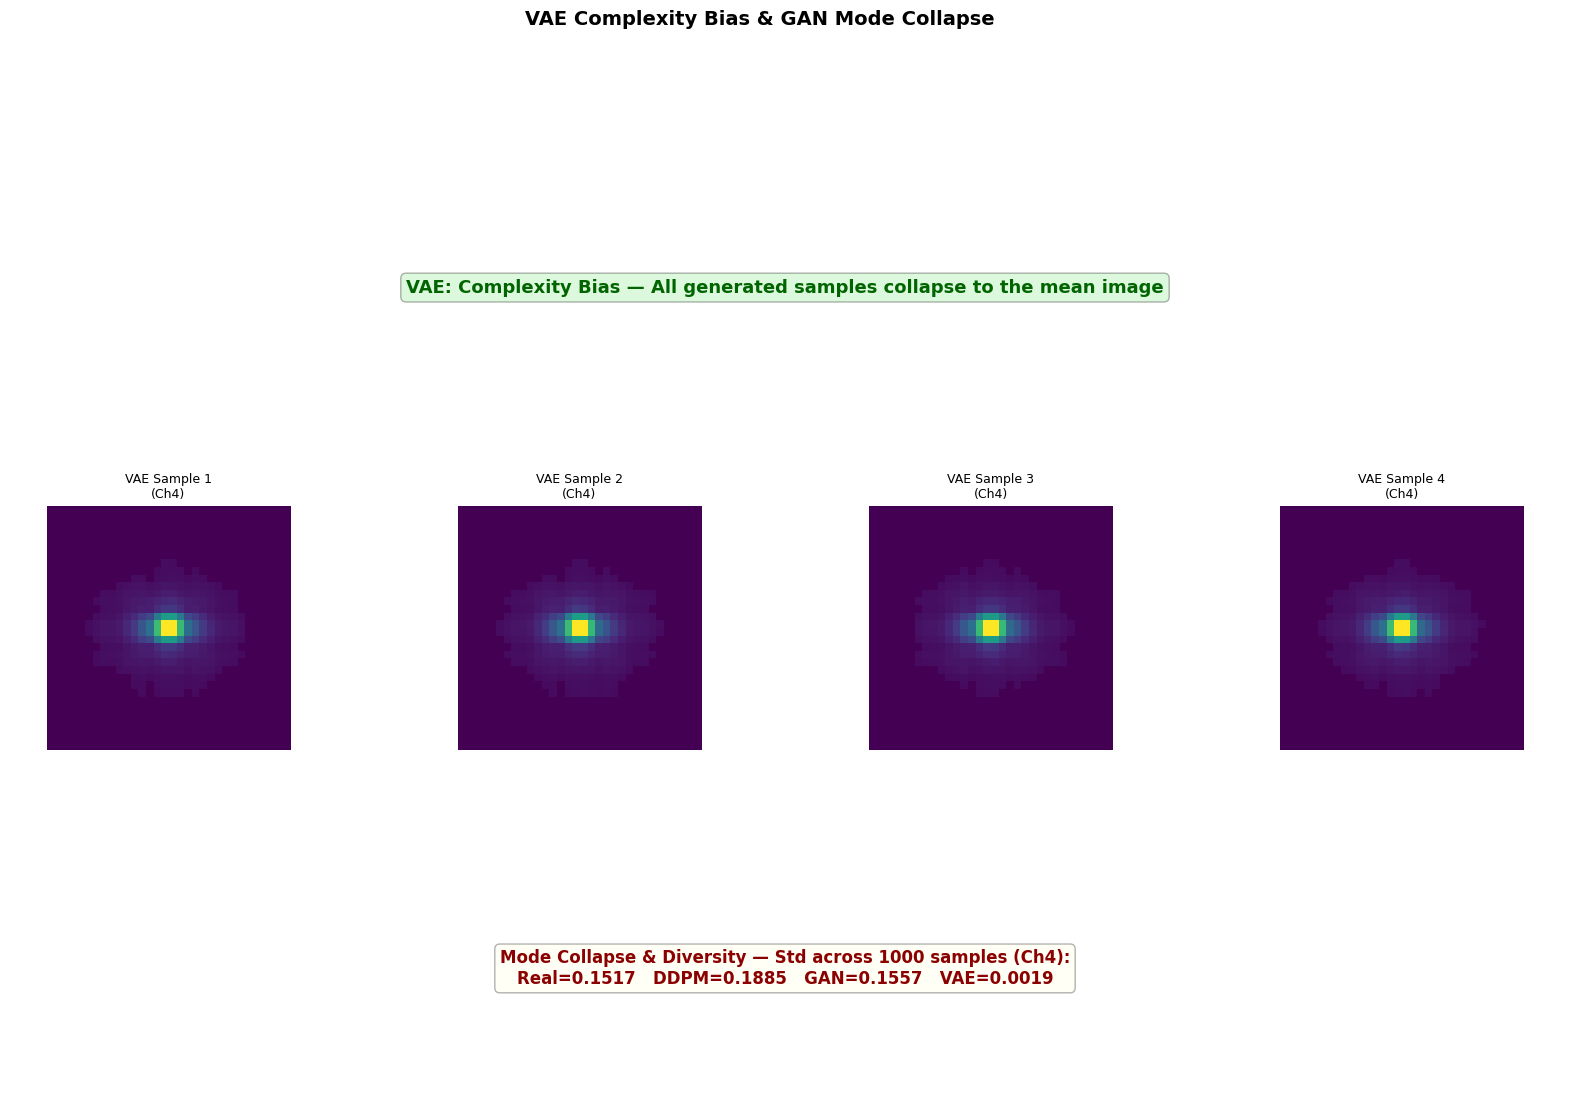

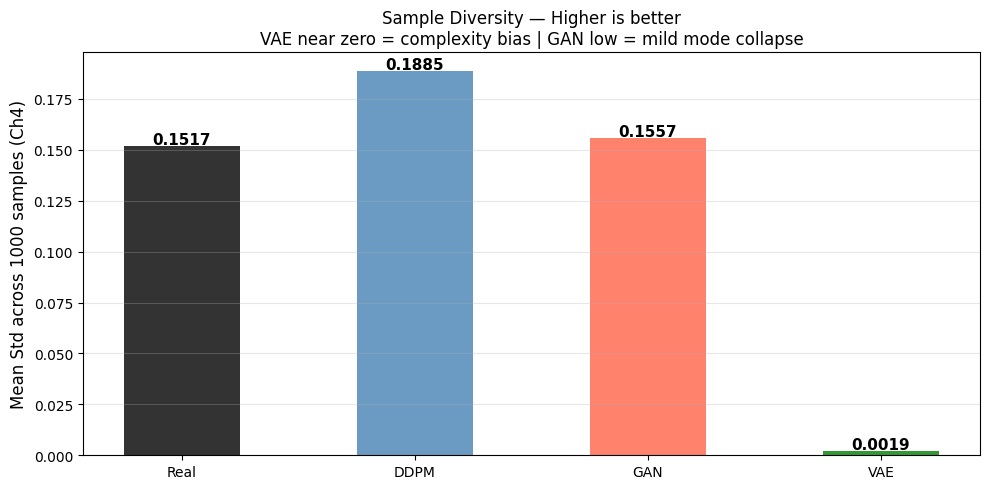


Diversity (std) per model — Ch4:
  Real: 0.1517
  DDPM: 0.1885
  GAN:  0.1557
  VAE:  0.0019


In [8]:
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

# ── Row 1: Complexity Bias (VAE) ──────────────────────────────────────
ax_title1 = fig.add_subplot(gs[0, :])
ax_title1.axis('off')
ax_title1.text(0.5, 0.5,
    "VAE: Complexity Bias — All generated samples collapse to the mean image",
    ha='center', va='center', fontsize=13, fontweight='bold', color='darkgreen',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# show 4 VAE samples — they all look identical
for i in range(4):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(vae_gen_np[i, 4], cmap='viridis')
    ax.set_title(f"VAE Sample {i+1}\n(Ch4)", fontsize=9)
    ax.axis('off')

# ── Row 2: Mode Collapse (GAN) ────────────────────────────────────────
ax_title2 = fig.add_subplot(gs[2, :])
ax_title2.axis('off')

# compute pairwise diversity — std of generated images
vae_std  = vae_gen_np[:, 4, :, :].std(axis=0).mean()
gan_std  = gan_gen_np[:, 4, :, :].std(axis=0).mean()
ddpm_std = gen_np[:,    4, :, :].std(axis=0).mean()
real_std = real_np[:,   4, :, :].std(axis=0).mean()

ax_title2.text(0.5, 0.5,
    f"Mode Collapse & Diversity — Std across 1000 samples (Ch4):\n"
    f"Real={real_std:.4f}   DDPM={ddpm_std:.4f}   "
    f"GAN={gan_std:.4f}   VAE={vae_std:.4f}",
    ha='center', va='center', fontsize=12, fontweight='bold', color='darkred',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.3))

plt.suptitle("VAE Complexity Bias & GAN Mode Collapse",
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig("bonus_task4_failures.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Diversity bar chart ───────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
models_div  = ['Real', 'DDPM', 'GAN', 'VAE']
stds        = [real_std, ddpm_std, gan_std, vae_std]
colors_div  = ['black', 'steelblue', 'tomato', 'green']

bars = ax.bar(models_div, stds, color=colors_div, alpha=0.8, width=0.5)
ax.set_ylabel("Mean Std across 1000 samples (Ch4)", fontsize=12)
ax.set_title("Sample Diversity — Higher is better\n"
             "VAE near zero = complexity bias | GAN low = mild mode collapse",
             fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("diversity_comparison.png", dpi=150)
plt.show()

print(f"\nDiversity (std) per model — Ch4:")
print(f"  Real: {real_std:.4f}")
print(f"  DDPM: {ddpm_std:.4f}")
print(f"  GAN:  {gan_std:.4f}")
print(f"  VAE:  {vae_std:.4f}")